In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cavity import Cavity
from bandstructure_class import BandStructureSim

import tidy3d as td
C0 = td.constants.C_0

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
import tidy3d.web as web

#API_KEY = 'QUlEQVhXQ09XSkdKSDNVSlNTR1ZWOnRpZHkzZDpNZkVabmFnaHo5Z0JrUEdObU5BakxVOTJkZkdZNTFta2l0TEZxSjk4a0hWYTFYN3UzY3NadXFMVGFid1I0Zm9lNlAyUEhDblN0eVcyUWtoaW4zYzlUUjNEMjZZU0VZallCQ09yaXhvZXF6WDVzN2VtVUJLUDlKWDVUVUI2VGdSdA=='
API_KEY = 'WdCHXGgLq3X51yJLrqnnEljRM2NxzlJOXU4ZL6i3SKPDs9Cm'

web.configure(API_KEY)
web.test()

API key configured successfully.


18:12:21 PDT Authentication configured successfully!

# TEST

In [ ]:
thickness = 0.25
width = 0.6
wl0 = 0.78
freq0 = C0 / wl0

n_cells = {
    "N_left_taper":    1,
    "N_left_mirror":  5,
    "N_defect":       40,   # odd → includes a central cell
    "N_right_mirror": 30,
    "N_right_taper":   1,
}

parameters = {
    "parameters_taper_left":    {"lattice": 0.27, "hole_params": np.array([0.01, 0.01])},
    "parameters_mirrors_left":  {"lattice": 0.3, "hole_params": np.array([0.2, 0.26])},
    "parameters_defect":        {"lattice": 0.26,  "hole_params": np.array([0.2, 0.26])},
    "parameters_mirrors_right": {"lattice": 0.3, "hole_params": np.array([0.2, 0.26])},
    "parameters_taper_right":   {"lattice": 0.27, "hole_params": np.array([0.01, 0.01])},
}

fwidth = freq0 * 0.01

context = {
    "freq0":          freq0,       
    "fwidth":         fwidth,        # bandwidth
    "thickness":      thickness,       # slab thickness (µm)
    "width":          width,       # waveguide width (µm)
    "polarization":   "Ey",       # dipole polarization (TE-like)
    "medium":         "materials/SiN.txt",          # material name (file-based dispersion) or refractive index
    "mode":           "dielectric",
    "sidewall_angle":  0,
    "geometry":       "ellipse",  # hole shape: 'ellipse' or 'square'
}

cavity = Cavity(n_cells=n_cells, parameters=parameters, context=context)

sim = cavity.build_simulation(
    grid_size_override=(0.01, 0.01, 0.01),  # coarser mesh for quick testing
    num_modes=1,
    plot=False,  # show mode solve results
)

for s in cavity.simulation.sim.structures:
    print(s.name, s.medium)


Output()

18:12:22 PDT WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'.                                

Nanobeam td.PoleResidue(
	eps_inf=1.000000000000132, 
	poles=(((-3.280707835675395-1.348644352623227e+16j), (1.2302281838699727+1.9514209460281028e+16j)),), 
	frequency_range=None)
Nanobeam_holes attrs={} name=None frequency_range=None allow_gain=False nonlinear_spec=None modulation_spec=None viz_spec=None heat_spec=None type='Medium' permittivity=1.0 conductivity=0.0


In [4]:
sim_obj = cavity.simulation

sim_obj.upload(directory="test", save_name="test2")
sim_obj.estimate_cost()
sim_data = sim_obj.run(directory="test", save_name="test2")


18:13:01 PDT Created task 'test2' with task_id                                  
             'fdve-eaea202b-293a-4f38-8ac2-97a966e789bc' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=709896;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eaea202b-293a-4f38-8ac2-97a966e789bc\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=916667;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eaea202b-293a-4f38-8ac2-97a966e789bc\taskId]8;;\]8;id=709896;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eaea202b-293a-4f38-8ac2-97a966e789bc\=]8;;\]8;id=758475;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eaea202b-293a-4f38-8ac2-97a966e789bc\fdve]8;;\]8;id=709896;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eaea202b-293a-4f38-8ac2-97a966e789bc\-eaea202b-293]8;;\
             ]8;id=709896;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eaea202b-293a-4f38-8ac2-97a966e789bc\a-4f38-8ac2-97a966e789bc']8;;\.

             Task folder: ]8;id=573479;https://tidy3d.simulation.cloud/folders/folder-e5e5984b-1737-4fb9-8b41-598ee3301f29\'test']8;;\.

Output()

18:13:03 PDT Maximum FlexCredit cost: 0.801. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

18:20:12 PDT View simulation result at                                          
             ]8;id=194853;https://tidy3d.simulation.cloud/workbench?taskId=fdve-270fd7c4-83f6-4388-8258-8a9e2877f989\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=310249;https://tidy3d.simulation.cloud/workbench?taskId=fdve-270fd7c4-83f6-4388-8258-8a9e2877f989\taskId]8;;\]8;id=194853;https://tidy3d.simulation.cloud/workbench?taskId=fdve-270fd7c4-83f6-4388-8258-8a9e2877f989\=]8;;\]8;id=951467;https://tidy3d.simulation.cloud/workbench?taskId=fdve-270fd7c4-83f6-4388-8258-8a9e2877f989\fdve]8;;\]8;id=194853;https://tidy3d.simulation.cloud/workbench?taskId=fdve-270fd7c4-83f6-4388-8258-8a9e2877f989\-270fd7c4-83f]8;;\
             ]8;id=194853;https://tidy3d.simulation.cloud/workbench?taskId=fdve-270fd7c4-83f6-4388-8258-8a9e2877f989\6-4388-8258-8a9e2877f989']8;;\.

Output()

18:20:23 PDT loading simulation from test/test2.hdf5

18:20:24 PDT WARNING: Simulation final field decay value of 0.188 is greater    
             than the simulation shutoff threshold of 1e-05. Consider running   
             the simulation again with a larger 'run_time' duration for more    
             accurate results.                                                  

Results saved: test/test2.hdf5


=== Resonance Analysis ===
                     decay             Q      amplitude     phase     error  \
freq                                                                          
3.862242e+14  3.647379e+08  3.326660e+06  216922.260645  2.801957  0.008095   

                    wl  
freq                    
3.862242e+14  0.776214  

Best resonance: f = 3.8622e+14 Hz, Q = 3326660

=== Energy Density ===
<xarray.DataArray (x: 338, y: 11, z: 13)> Size: 387kB
array([[[3.99073254, 3.99073254, 3.99073254, ..., 1.        ,
         1.        , 1.        ],
        [3.99073254, 3.99073254, 3.99073254, ..., 1.        ,
         1.        , 1.        ],
        [3.99073254, 3.99073254, 3.99073254, ..., 1.        ,
         1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.      

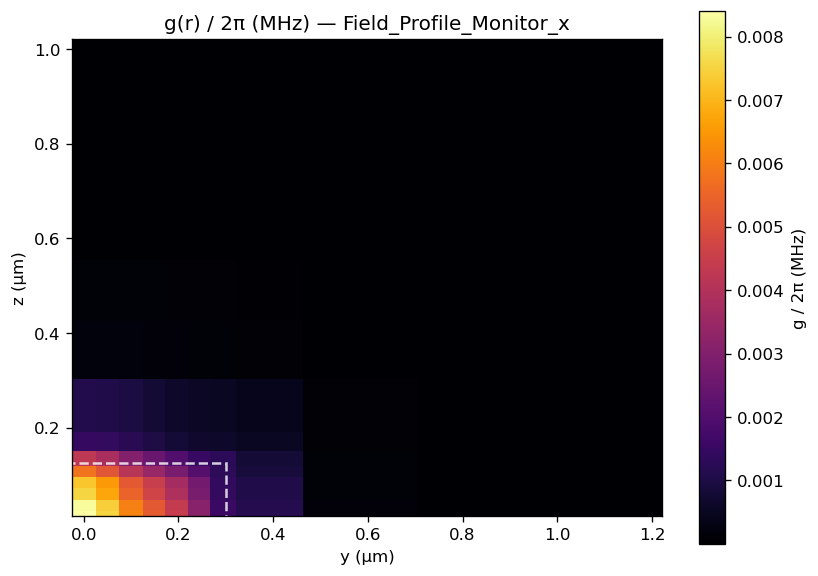

In [5]:

cavity.simulation.full_analysis()

for s in cavity.simulation.sim.structures:
    print(s.name, s.medium)


mu_reduced = 3.58e-29  # C·m, full D2 reduced matrix element
mu_cycling = np.sqrt(1/2) * mu_reduced  # ≈ 2.53e-29 C·m
g_map, g_max = cavity.simulation.coupling_g(dipole_moment=mu_cycling, monitor_name="Field_Profile_Monitor_x", polarization_component="Ey", plot=True)

Output()

=== Resonance Analysis ===
                     decay             Q      amplitude     phase     error  \
freq                                                                          
3.862242e+14  3.647379e+08  3.326660e+06  216922.260645  2.801957  0.008095   

                    wl  
freq                    
3.862242e+14  0.776214  

Best resonance: f = 3.8622e+14 Hz, Q = 3326660

=== Energy Density ===
Energy density computed.

=== Mode Volume [um³] ===
Mode volume: 0.8168 (λ[um]/n)³

=== Directional Q ===
Q_+x = 323.22 M
Q_-x = 58.13 M
Q_+y = 2.32 M
Q_-y = 2.32 M
Q_+z = 1.34 M
Q_-z = 1.34 M
Q_total = 0.42 M

=== Directional kappa ===
  κ_+x / 2π = 0.001 GHz
  κ_-x / 2π = 0.007 GHz
  κ_+y / 2π = 0.167 GHz
  κ_-y / 2π = 0.167 GHz
  κ_+z / 2π = 0.288 GHz
  κ_-z / 2π = 0.288 GHz
  κ_total / 2π = 0.917 GHz

=== Summary ===
  Q (resonance finder): 3326660
  Kappa (total): 0.116 GHz
  Q (directional total): 0.42 M
  Mode volume: 0.8168 in units of (λ[um]/n)³
  Purcell factor estimate: 

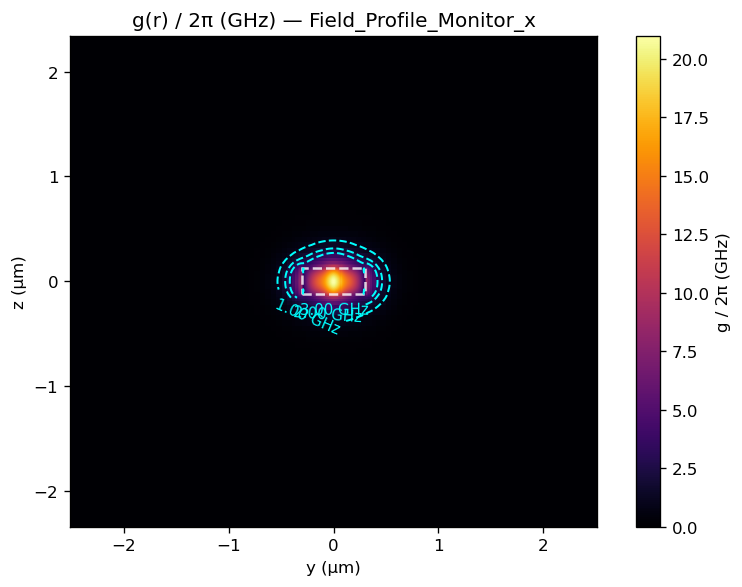

  g(r) / 2π = 19.7839 GHz
  κ / 2π    = 0.1161 GHz
  κ_-x / 2π = 0.0066 GHz
  γ / 2π    = 6.1469 MHz
  C         = 2193791.34
  Collection efficiency into -x: 5.67%   (assuming fiber coupling efficiency 99.0%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from cavity import Cavity
from bandstructure_class import BandStructureSim

import tidy3d as td
C0 = td.constants.C_0

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

cavity = Cavity.from_simulation("test/test2.hdf5")
cavity.simulation.full_analysis()

mu_reduced = 3.58e-29  # C·m, full D2 reduced matrix element
mu_cycling = np.sqrt(1/2) * mu_reduced  # ≈ 2.53e-29 C·m
g_map, g_max = cavity.simulation.coupling_g(dipole_moment=mu_cycling, monitor_name="Field_Profile_Monitor_x", polarization_component="Ey", plot=True, contour_ghz=[1,2,3])

C = cavity.simulation.cooperativity(
    dipole_moment=mu_cycling,
    position={"y": 0.0, "z": 0.2},
    channel="-x",  
    monitor_name="Field_Profile_Monitor_x", 
    polarization_component="Ey"
)


Output()

Mode volume: 0.1629 (λ[um]/n)³
=== Resonance Analysis ===
                     decay             Q     amplitude     phase     error  \
freq                                                                         
3.862242e+14  5.267617e+08  2.303431e+06  214562.64601 -1.546694  0.008065   

                    wl  
freq                    
3.862242e+14  0.776214  

Best resonance: f = 3.8622e+14 Hz, Q = 2303431

=== Energy Density ===
Energy density computed.

=== Mode Volume [um³] ===
Mode volume: 0.1629 (λ[um]/n)³

=== Directional Q ===
Q_+x = 127.84 M
Q_-x = 23.14 M
Q_+y = 0.92 M
Q_-y = 0.92 M
Q_+z = 0.53 M
Q_-z = 0.53 M
Q_total = 0.17 M

=== Summary ===
  Q (resonance finder): 2303431
  Q (directional total): 0.17 M
  Mode volume: 0.1629 in units of (λ[um]/n)³
  Purcell factor estimate: 1074504.9


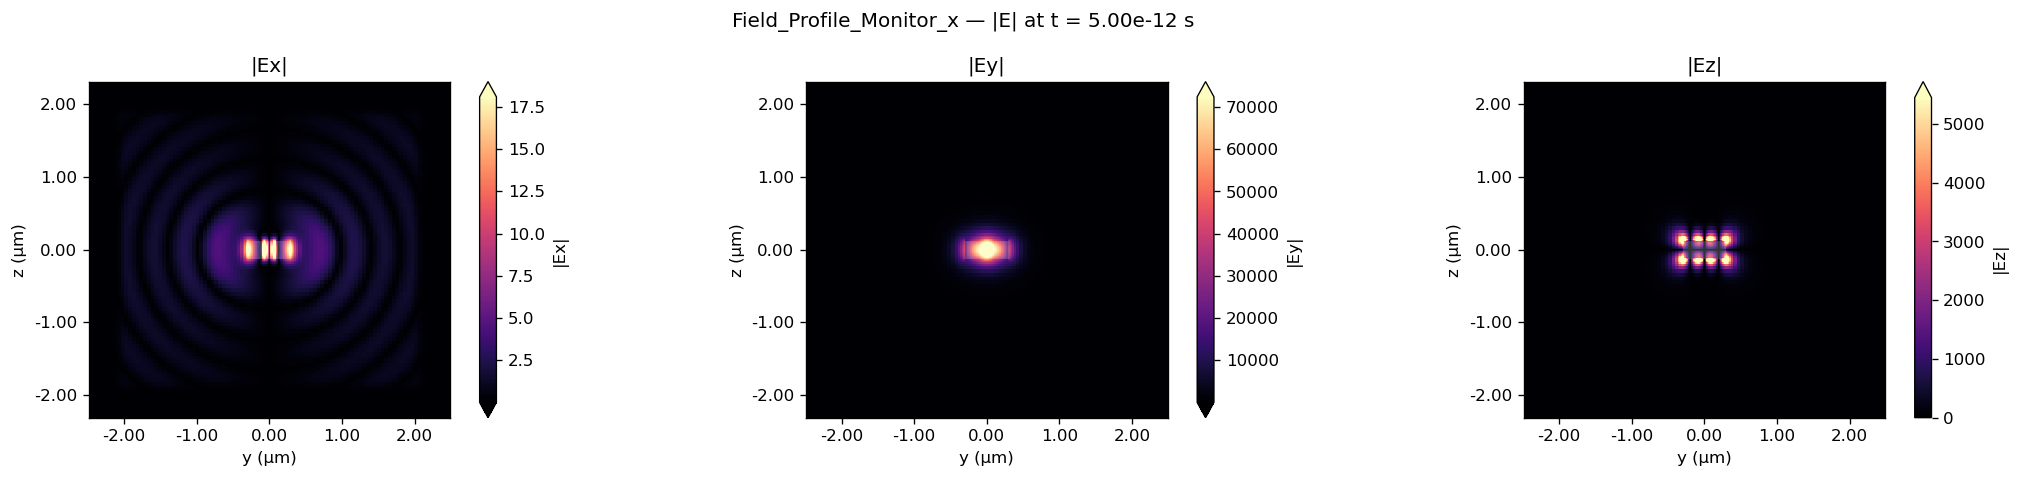

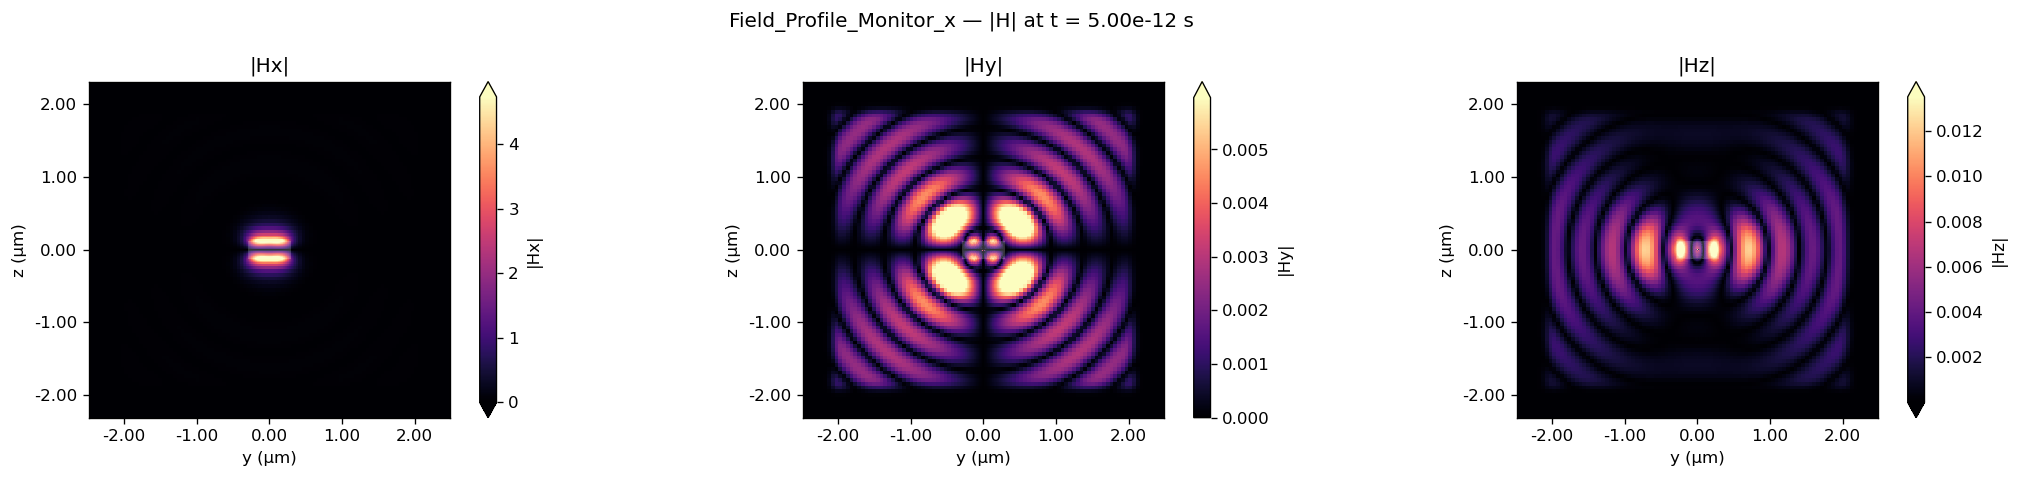

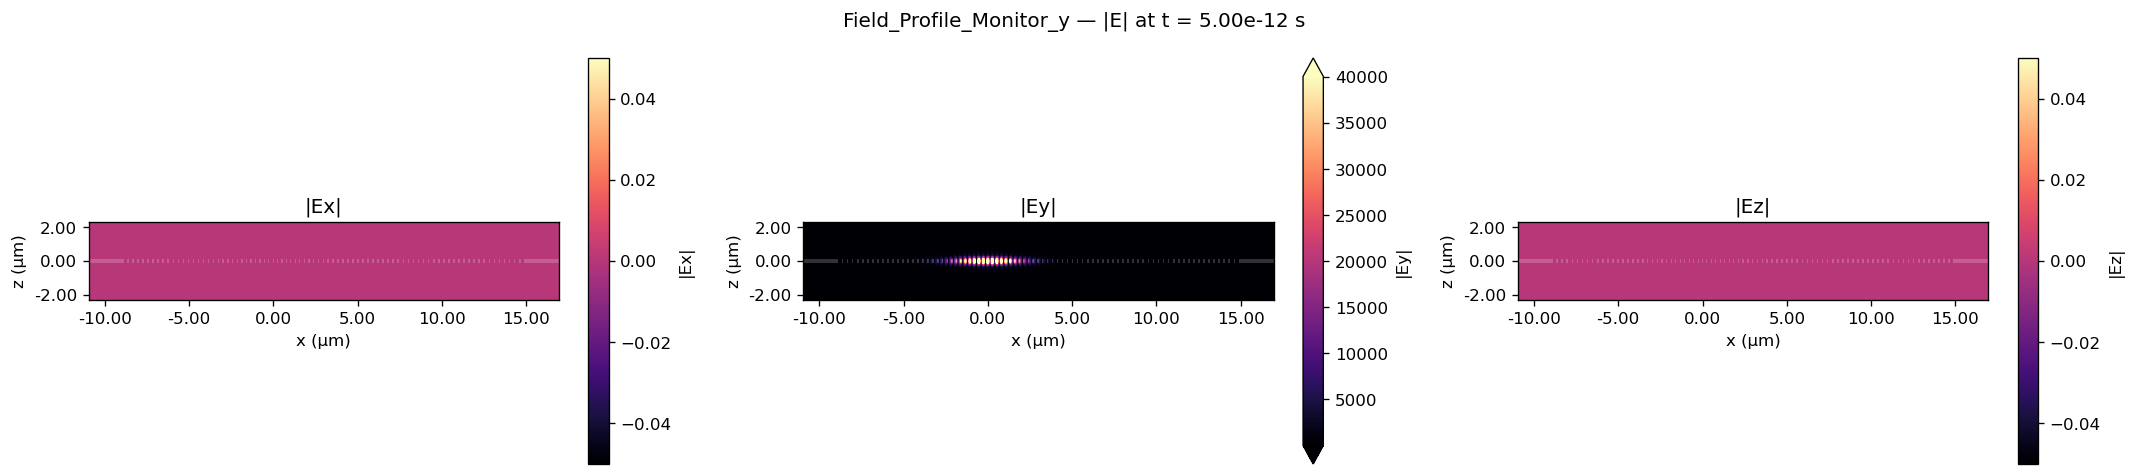

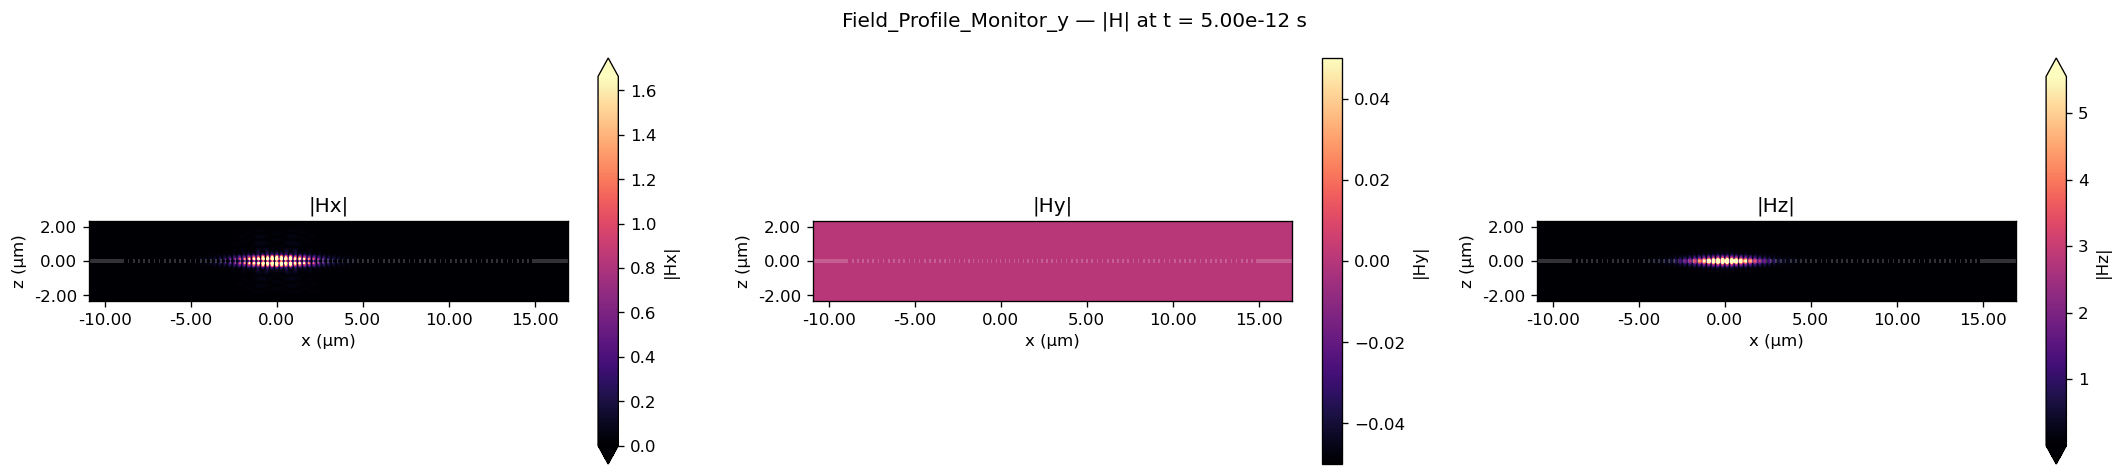

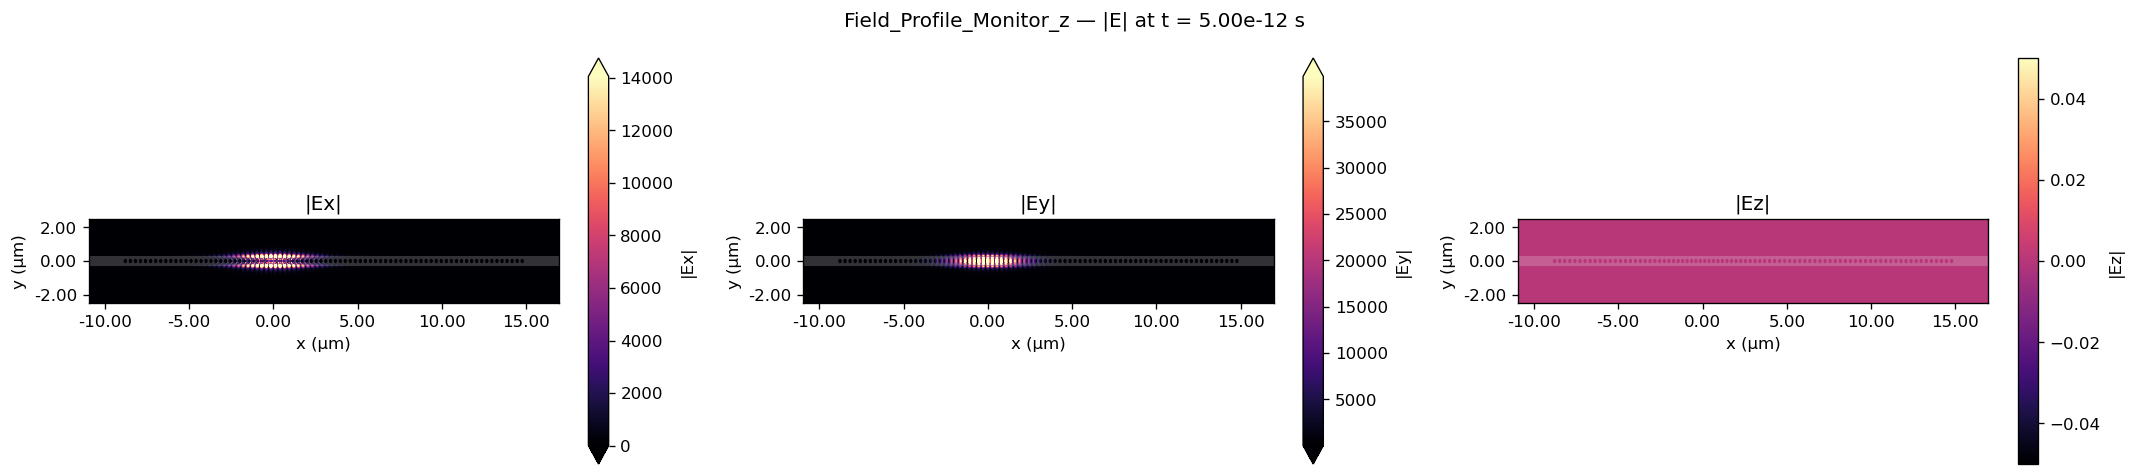

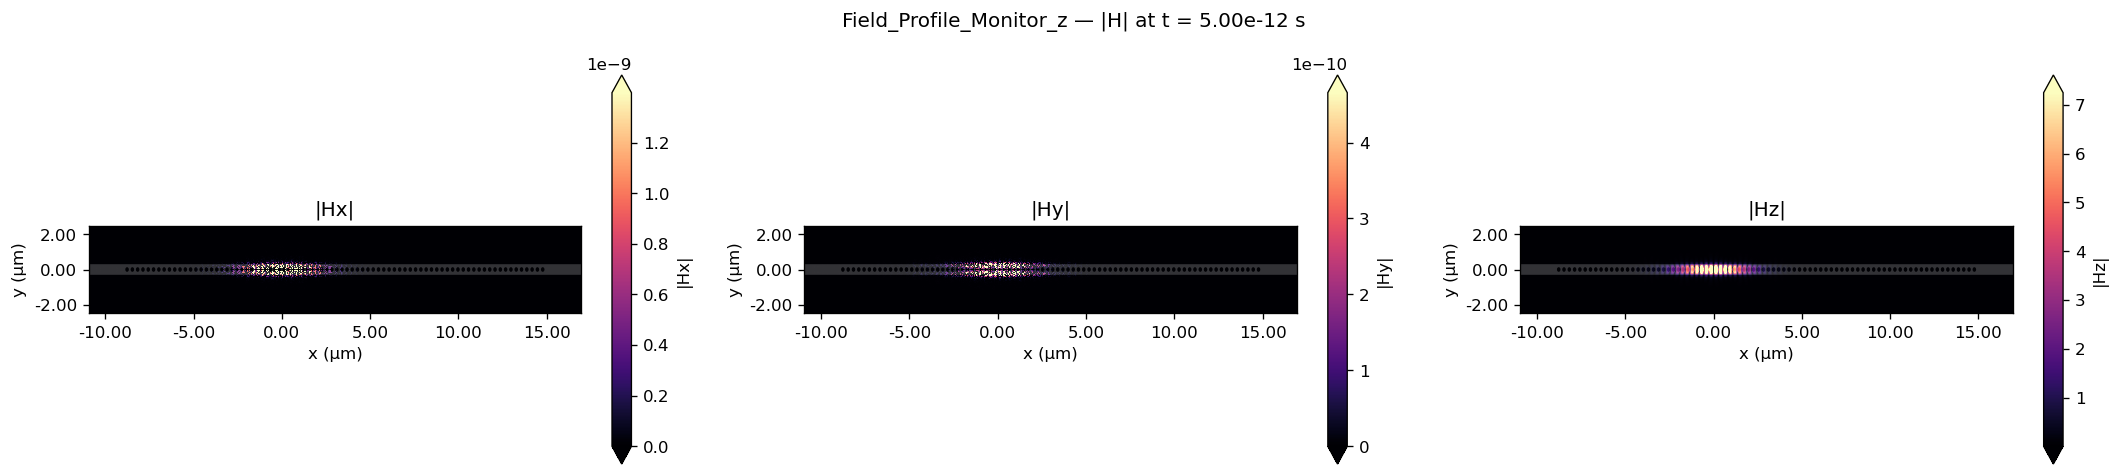

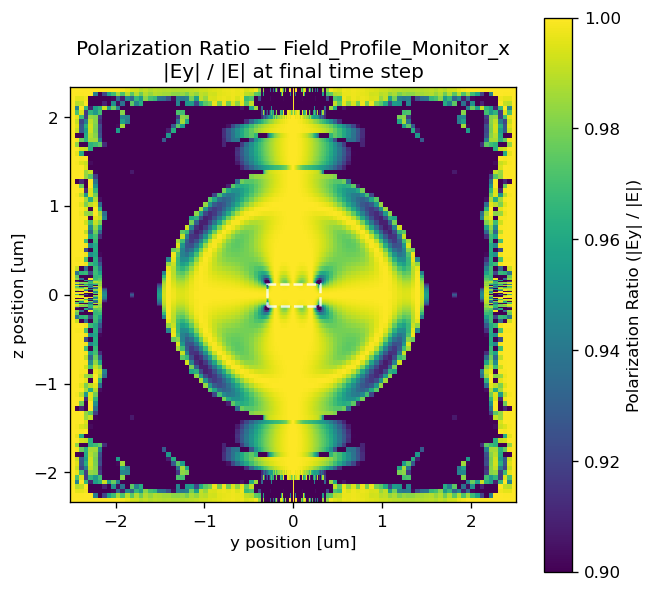

n_max:  <xarray.DataArray ()> Size: 8B
array(1.)
resonant w:  0.7762136070244123




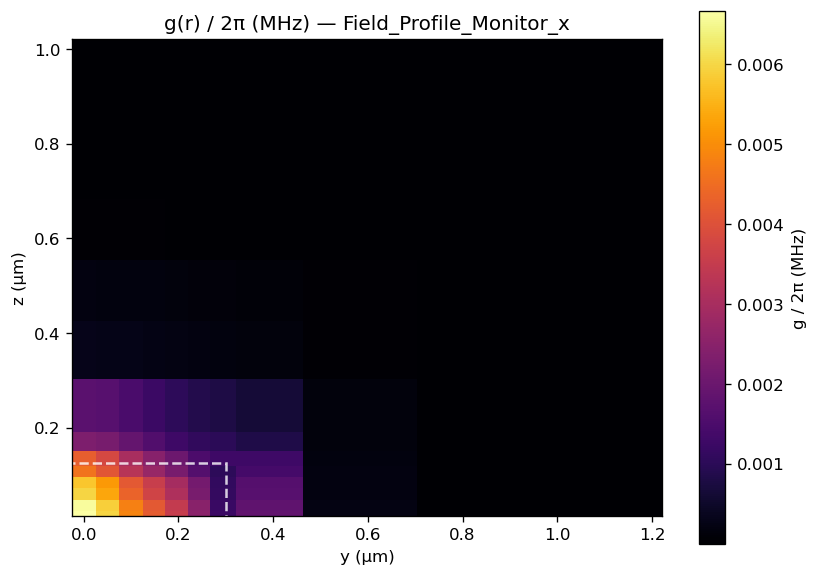

In [3]:
cavity = Cavity.from_simulation("test/test.hdf5")

# Now analysis works directly
cavity.simulation.analyse_resonances()
cavity.simulation.mode_volume()
cavity.simulation.full_analysis()
cavity.simulation.plot_results()

cavity.simulation.polarization_profile(monitor_name="Field_Profile_Monitor_x", polarization_component="Ey", plot=True)

mu_reduced = 3.58e-29  # C·m, full D2 reduced matrix element
mu_cycling = np.sqrt(1/2) * mu_reduced  # ≈ 2.53e-29 C·m
g_map, g_max = cavity.simulation.coupling_g(dipole_moment=mu_cycling, monitor_name="Field_Profile_Monitor_x", polarization_component="Ey", plot=True)

In [10]:
import tidy3d as td
import numpy as np
import tidy3d.web as web

C0 = td.constants.C_0

# Tweezer parameters (from the paper)
lambda_trap = 0.815       # µm (815 nm trapping wavelength)
freq_trap = C0 / lambda_trap
beam_waist = 0.9          # µm (900 nm beam waist)
fwidth = freq_trap / 10   # narrow bandwidth

# Nanobeam cross-section (from supplementary)
beam_width = 0.433        # µm (wx)
beam_thickness = 0.200    # µm (wy)

# The nanobeam medium (SiN, n ≈ 2.0)
sin_medium = td.Medium(permittivity=4.0)

# Simulation domain — we only need a few µm around the beam
sim_size = (4.0, 4.0, 4.0)

# The nanobeam structure (simplified as a rectangular slab along x)
nanobeam = td.Structure(
    geometry=td.Box(
        center=(0, 0, 0),
        size=(td.inf, beam_width, beam_thickness),
    ),
    medium=sin_medium,
    name="nanobeam",
)

# Focused Gaussian beam (the optical tweezer)
# Propagating in -z direction (coming from above, hitting the beam)
source = td.GaussianBeam(
    center=(0, 0, sim_size[2] / 2 - 0.5),  # launch from top
    size=(td.inf, td.inf, 0),
    source_time=td.GaussianPulse(
        freq0=freq_trap,
        fwidth=fwidth,
    ),
    direction="-",           # propagating downward toward beam
    waist_radius=beam_waist,
    waist_distance=sim_size[2] / 2 - 0.5,  # focus at z=0
    pol_angle=0,             # polarization along x
    name="tweezer",
)

# Field monitor — high resolution in the trapping region
field_monitor = td.FieldMonitor(
    center=(0, 0, 0),
    size=(0, beam_width * 3, beam_thickness * 6),  # yz plane at x=0
    freqs=[freq_trap],
    name="trapping_field",
)

sim = td.Simulation(
    center=(0, 0, 0),
    size=sim_size,
    structures=[nanobeam],
    sources=[source],
    monitors=[field_monitor],
    run_time=50 / fwidth,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=25),
)

In [11]:
sim_data = web.run(sim, task_name="trap", folder_name="test", path="test/trap.hdf5")

17:16:17 PDT Created task 'trap' with task_id                                   
             'fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=60970;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=984795;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\taskId]8;;\]8;id=60970;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\=]8;;\]8;id=321958;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\fdve]8;;\]8;id=60970;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\-2a9bd5f8-3ad]8;;\
             ]8;id=60970;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\c-448d-a6a1-1e962e046cb1']8;;\.

             Task folder: ]8;id=41685;https://tidy3d.simulation.cloud/folders/folder-e5e5984b-1737-4fb9-8b41-598ee3301f29\'test']8;;\.

Output()

17:16:18 PDT Maximum FlexCredit cost: 0.096. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

Output()

17:16:33 PDT status = success

17:16:35 PDT View simulation result at                                          
             ]8;id=450882;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=476716;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\taskId]8;;\]8;id=450882;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\=]8;;\]8;id=149523;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\fdve]8;;\]8;id=450882;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\-2a9bd5f8-3ad]8;;\
             ]8;id=450882;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2a9bd5f8-3adc-448d-a6a1-1e962e046cb1\c-448d-a6a1-1e962e046cb1']8;;\.

Output()

17:16:36 PDT loading simulation from test/trap.hdf5

In [12]:
from scipy.constants import hbar, k as kB, c, epsilon_0

# Rb D2 line parameters
lambda_atom = 780.241e-9   # m
Gamma = 2 * np.pi * 6.07e6 # natural linewidth (rad/s)
delta = 2 * np.pi * c * (1/lambda_trap*1e-6 - 1/lambda_atom)  # detuning (rad/s)

# Scalar polarizability for far-detuned trap (two-level approximation)
# alpha' = 3*pi*eps0*c^3 * Gamma / (omega_atom^2 * delta)
omega_atom = 2 * np.pi * c / lambda_atom
alpha_prime = 3 * np.pi * epsilon_0 * c**3 * Gamma / (omega_atom**3 * delta)

# Extract intensity from simulation
E_data = sim_data["trapping_field"]
intensity = (np.abs(E_data.Ex)**2 + np.abs(E_data.Ey)**2 + np.abs(E_data.Ez)**2).squeeze()

# Optical dipole potential: U = -alpha'/2 * |E|^2
# But we need to convert from Tidy3D units to SI
# Tidy3D fields are normalized — you need to scale by the actual tweezer power
# For U0/kB = 1.6 mK (paper value), calibrate the peak intensity

# Casimir-Polder potential (simplified model from supplementary)
C3_hz = 1500  # Hz·µm³ for Rb-SiN
lambda_eff = 0.650  # µm
C3 = 2 * np.pi * hbar * C3_hz * 1e-18  # convert to J·m³

def casimir_polder(z_um):
    """z_um: distance from surface in µm. Returns potential in Joules."""
    z_m = z_um * 1e-6
    leff_m = lambda_eff * 1e-6
    return -C3 * leff_m / (2 * np.pi) / (z_m**3 * (z_m + leff_m / (2 * np.pi)))

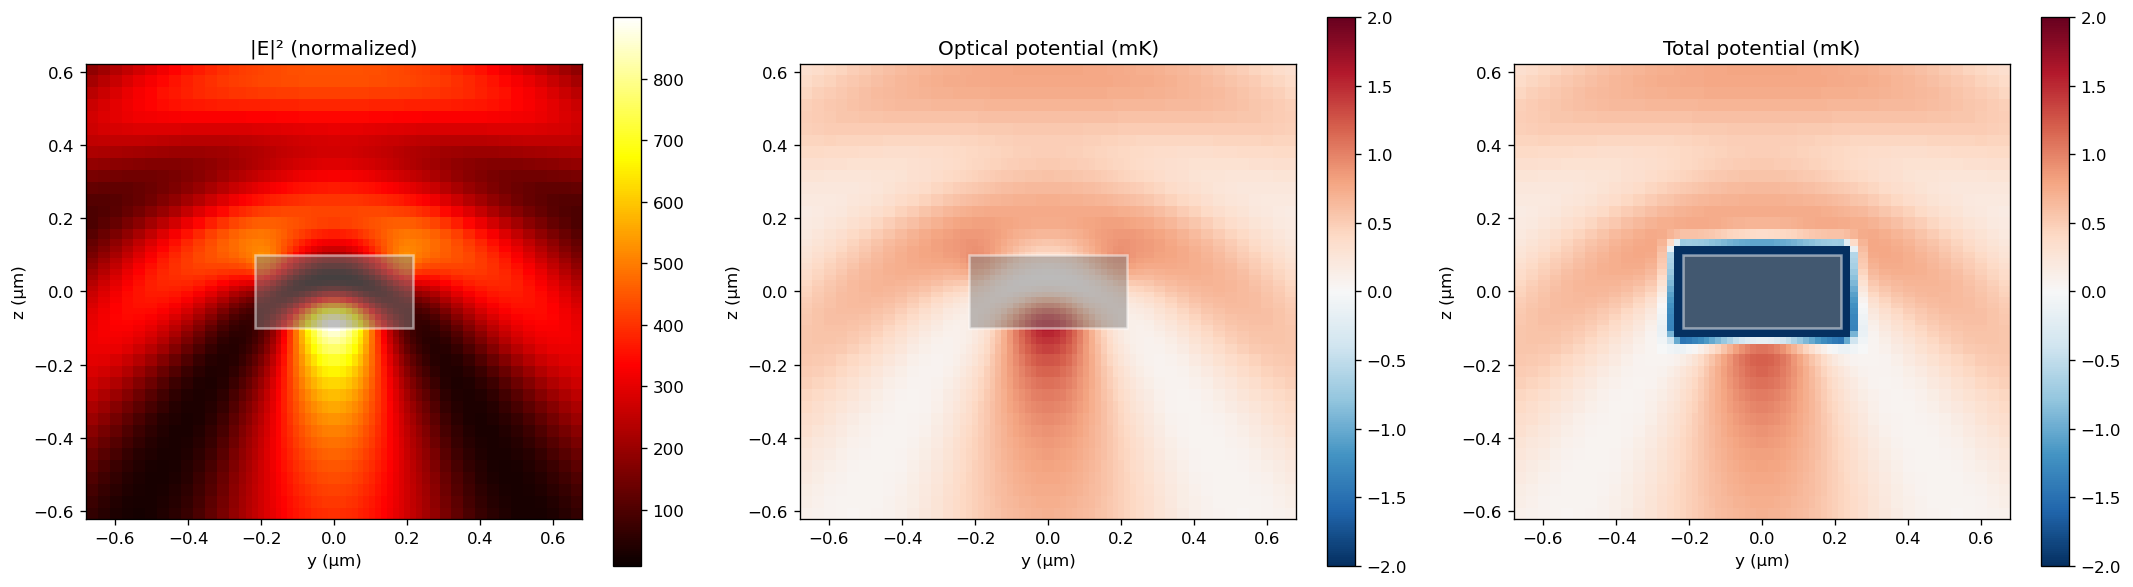

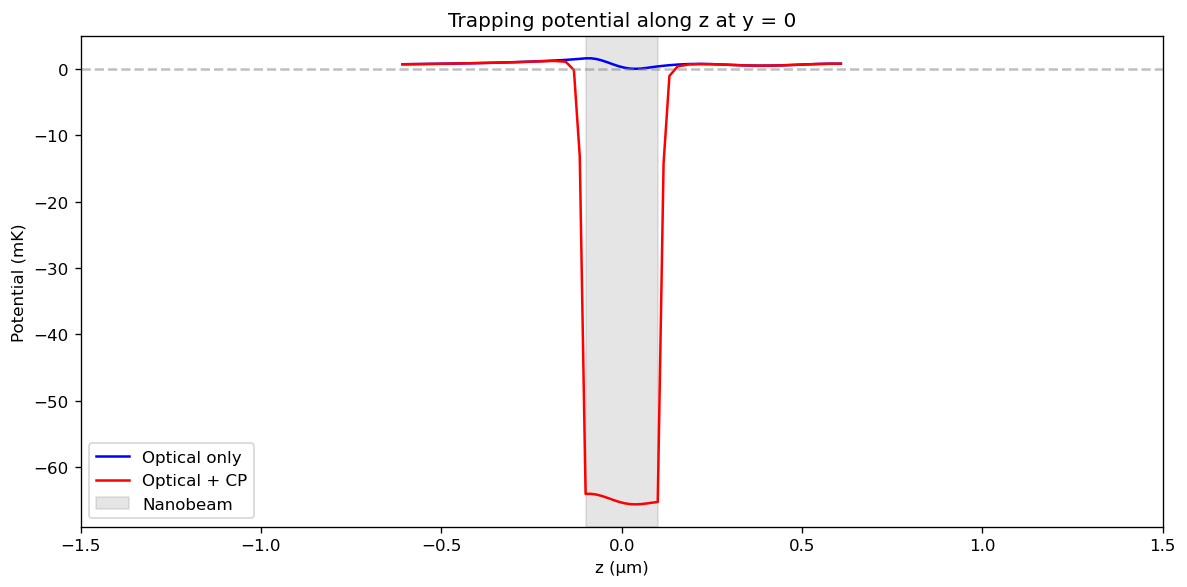

In [13]:
# --- 1. Calibrate intensity to get the optical potential ---
# Tidy3D normalizes fields, so scale to match the known trap depth
# Paper: U0/kB = 1.6 mK
U0_joules = kB * 1.6e-3  # trap depth in Joules

# The raw optical potential (proportional, not yet calibrated)
U_opt_raw = -0.5 * alpha_prime * intensity  # shape: (y, z)

# Scale so that the deepest point in free space matches U0
# In free space (far from structure), the potential minimum is just the beam focus
scale_factor = U0_joules / np.abs(U_opt_raw).max()
U_opt = U_opt_raw * scale_factor  # now in Joules

# --- 2. Add Casimir-Polder surface potential ---
# Distance from the nearest surface of the nanobeam
y_vals = intensity.y.values  # µm
z_vals = intensity.z.values  # µm

beam_half_w = beam_width / 2    # half-width in y
beam_half_t = beam_thickness / 2  # half-thickness in z

# Distance to the closest surface (rectangular cross-section)
Y, Z = np.meshgrid(y_vals, z_vals, indexing="ij")
dist_y = np.maximum(np.abs(Y) - beam_half_w, 0)
dist_z = np.maximum(np.abs(Z) - beam_half_t, 0)
dist_surface = np.sqrt(dist_y**2 + dist_z**2)  # µm

# Avoid divergence at the surface
dist_surface = np.clip(dist_surface, 0.01, None)  # clip at 10 nm

U_cp = casimir_polder(dist_surface)  # Joules

# Total potential
U_total = U_opt.values + U_cp  # Joules

# Convert to convenient units: MHz (U / hbar) or mK (U / kB)
U_mK = U_total / kB * 1e3  # in mK
U_MHz = U_total / (hbar * 2 * np.pi * 1e6)  # in MHz

# --- 3. Plot the intensity ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw |E|² intensity
im0 = axes[0].pcolormesh(y_vals, z_vals, np.abs(intensity.values).T,
                          cmap="hot", shading="auto")
axes[0].set_title("|E|² (normalized)")
axes[0].set_xlabel("y (µm)")
axes[0].set_ylabel("z (µm)")
axes[0].set_aspect("equal")
fig.colorbar(im0, ax=axes[0])

# Optical potential only (in mK)
U_opt_mK = U_opt.values / kB * 1e3
im1 = axes[1].pcolormesh(y_vals, z_vals, U_opt_mK.T,
                          cmap="RdBu_r", shading="auto",
                          vmin=-2, vmax=2)
axes[1].set_title("Optical potential (mK)")
axes[1].set_xlabel("y (µm)")
axes[1].set_ylabel("z (µm)")
axes[1].set_aspect("equal")
fig.colorbar(im1, ax=axes[1])

# Total potential (optical + Casimir-Polder)
im2 = axes[2].pcolormesh(y_vals, z_vals, U_mK.T,
                          cmap="RdBu_r", shading="auto",
                          vmin=-2, vmax=2)
axes[2].set_title("Total potential (mK)")
axes[2].set_xlabel("y (µm)")
axes[2].set_ylabel("z (µm)")
axes[2].set_aspect("equal")
fig.colorbar(im2, ax=axes[2])

# Draw nanobeam outline on all panels
for ax in axes:
    rect = plt.Rectangle((-beam_half_w, -beam_half_t),
                          beam_width, beam_thickness,
                          edgecolor="white", facecolor="gray",
                          alpha=0.5, linewidth=1.5)
    ax.add_patch(rect)

plt.tight_layout()
plt.show()

# --- 4. Line cut along z (through the trap) ---
# Take a cut at y=0 to see the standing wave and trap sites
y_center_idx = np.argmin(np.abs(y_vals))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z_vals, U_opt_mK[y_center_idx, :], label="Optical only", color="blue")
ax.plot(z_vals, U_mK[y_center_idx, :], label="Optical + CP", color="red")
ax.axhline(0, color="gray", ls="--", alpha=0.5)
ax.axvspan(-beam_half_t, beam_half_t, alpha=0.2, color="gray", label="Nanobeam")
ax.set_xlabel("z (µm)")
ax.set_ylabel("Potential (mK)")
ax.set_title("Trapping potential along z at y = 0")
ax.legend()
ax.set_xlim(-1.5, 1.5)
plt.tight_layout()
plt.show()

# COMPARISON 150 vs 250 nm 

384349305128205.1
Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 80 x 135.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 5, 0)
     (0, 0, 8.33333)
Cell volume = 41.6667
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.2, -0)
     (0, -0, 0.12)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1,0.833333)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.333333,0.333333,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -2.5625..2.5625, -4.2284..4.2284)
          bounding box (-0.166667..0.166667, -0.166667..0.166667, -5e+19..5e+19)
          shift object by (0, 0, -8.33333)
          ellipsoid, center = (0,0,0)
               size (0.333333,0.333333,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding 

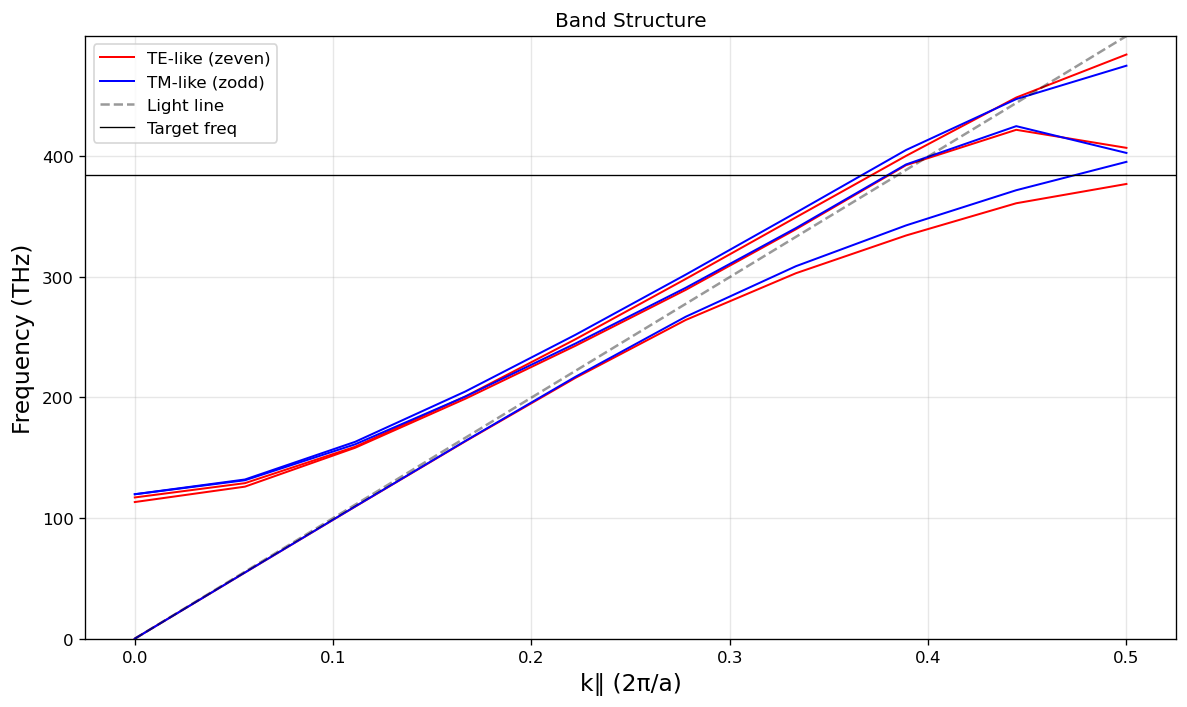

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 80 x 135.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 5, 0)
     (0, 0, 8.33333)
Cell volume = 41.6667
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.2, -0)
     (0, -0, 0.12)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1,0.833333)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.333333,0.333333,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -2.5625..2.5625, -4.2284..4.2284)
          bounding box (-0.166667..0.166667, -0.166667..0.166667, -5e+19..5e+19)
          shift object by (0, 0, -8.33333)
          ellipsoid, center = (0,0,0)
               size (0.333333,0.333333,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding box (-0.166667..0.

SystemError: <built-in function mode_solver_solve_kpoint> returned a result with an exception set

In [58]:
thickness = 0.25
wl0 = 0.78
freq0 = C0 / wl0
print(freq0)

Lx = 0.3
Ly = 0.3
dx = 0.1
dy = 0.1

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)

sim.run_bandstructure(k_min=0, k_max=0.5, n_k=8)
sim.plot_bands(units='THz', freq0_Hz=freq0)

sim.run_at_k(kx=0.5)
freqs = sim.zeven_freqs
print(sim.freq_norm_to_THz(freqs[0]))

384349305128205.1
Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 80 x 80.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 5, 0)
     (0, 0, 5)
Cell volume = 25
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.2, -0)
     (0, -0, 0.2)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.333333,0.333333,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -2.5625..2.5625, -2.5625..2.5625)
          bounding box (-0.166667..0.166667, -0.166667..0.166667, -5e+19..5e+19)
          shift object by (0, 0, -5)
          ellipsoid, center = (0,0,0)
               size (0.333333,0.333333,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding box (-0.166667..0.166667

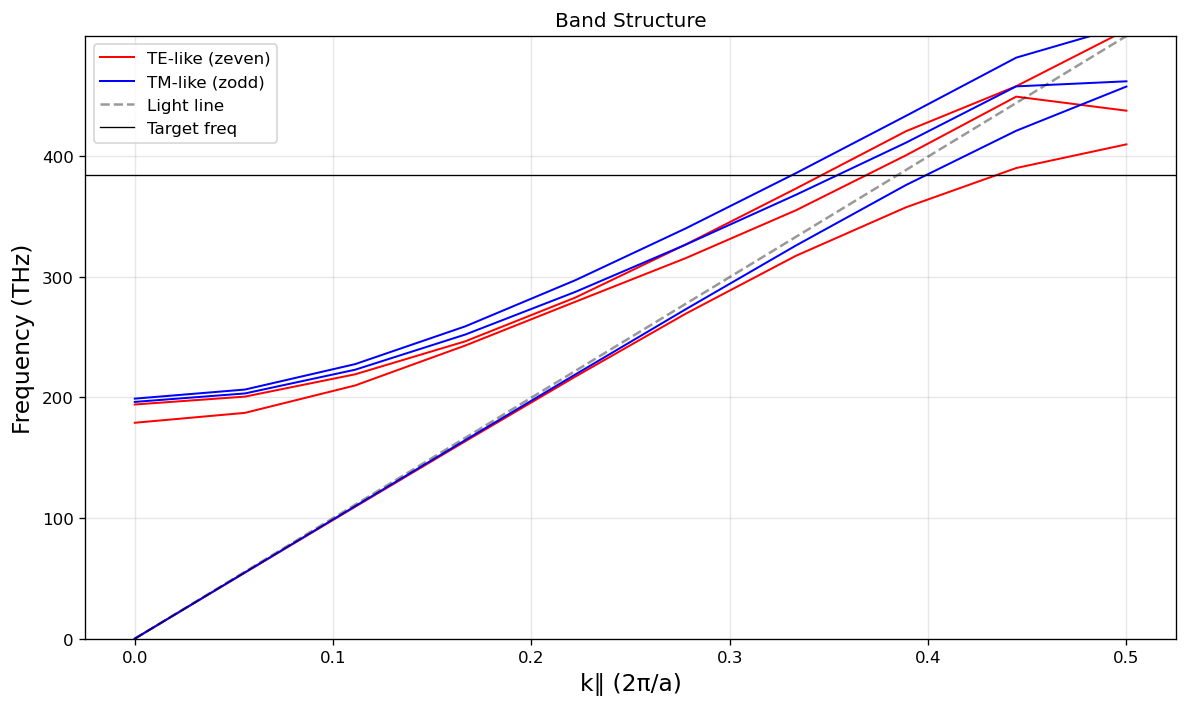

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 80 x 80.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 5, 0)
     (0, 0, 5)
Cell volume = 25
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.2, -0)
     (0, -0, 0.2)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.333333,0.333333,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -2.5625..2.5625, -2.5625..2.5625)
          bounding box (-0.166667..0.166667, -0.166667..0.166667, -5e+19..5e+19)
          shift object by (0, 0, -5)
          ellipsoid, center = (0,0,0)
               size (0.333333,0.333333,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding box (-0.166667..0.166667, -0.166667..0.166

In [ ]:
thickness = 0.15
wl0 = 0.78
freq0 = C0 / wl0
print(freq0)

Lx = 0.3
Ly = 0.3
dx = 0.1
dy = 0.1

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)

sim.run_bandstructure(k_min=0, k_max=0.5, n_k=8)
sim.plot_bands(units='THz', freq0_Hz=freq0)

sim.run_at_k(kx=0.5)
freqs = sim.zeven_freqs
print(sim.freq_norm_to_THz(freqs[0]))


## The frequencies at the band edge are shifted from [376.9799273  406.9220682  484.30117713] at 250nm for the first 3 bands to [409.81231763 437.73548673 504.64465093]. The shift for the first band edge is of 377 THz to 410 THz corresponding of a shift of 33 THz.

# Design 1

In [3]:
thickness = 0.15
width = 0.5
wl0 = 0.78
freq0 = C0 / wl0

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 140 x 84.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 8.62069, 0)
     (0, 0, 5.17241)
Cell volume = 44.5898
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.116, -0)
     (0, -0, 0.193333)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1.72414,0.517241)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.689655,0.689655,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -4.37192..4.37192, -2.64778..2.64778)
          bounding box (-0.344828..0.344828, -0.344828..0.344828, -5e+19..5e+19)
          shift object by (0, 0, -5.17241)
          ellipsoid, center = (0,0,0)
               size (0.689655,0.689655,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bound

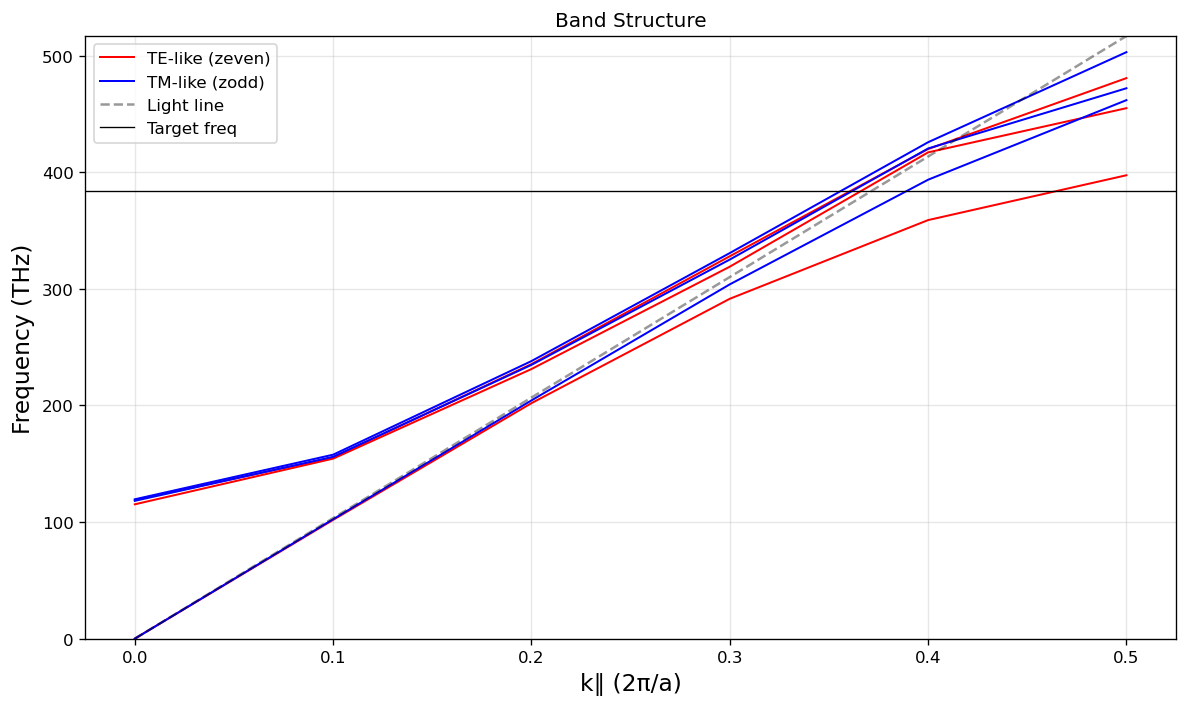

(<Figure size 1200x720 with 1 Axes>,
 <Axes: title={'center': 'Band Structure'}, xlabel='k∥ (2π/a)', ylabel='Frequency (THz)'>)

In [4]:
Lx = 0.29
Ly = width
dx = 0.2
dy = 0.2

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=4)
sim.plot_bands(units='THz', freq0_Hz=freq0)

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 125 x 75.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 7.57576, 0)
     (0, 0, 4.54545)
Cell volume = 34.4353
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.132, -0)
     (0, -0, 0.22)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1.51515,0.454545)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.606061,0.606061,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -3.84848..3.84848, -2.33333..2.33333)
          bounding box (-0.30303..0.30303, -0.30303..0.30303, -5e+19..5e+19)
          shift object by (0, 0, -4.54545)
          ellipsoid, center = (0,0,0)
               size (0.606061,0.606061,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding box 

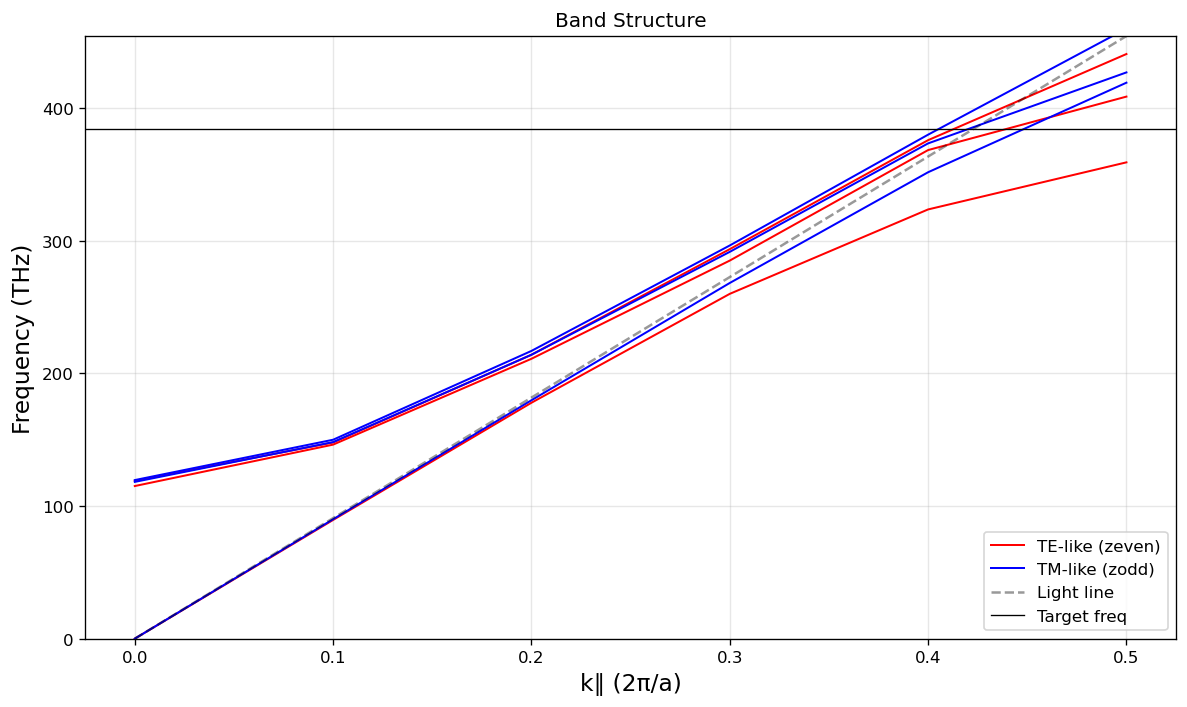

(<Figure size 1200x720 with 1 Axes>,
 <Axes: title={'center': 'Band Structure'}, xlabel='k∥ (2π/a)', ylabel='Frequency (THz)'>)

In [5]:
Lx = 0.33
Ly = width
dx = 0.2
dy = 0.2

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=4)
sim.plot_bands(units='THz', freq0_Hz=freq0)

In [ ]:
n_cells = {
    "N_left_taper":    5,
    "N_left_mirror":  10,
    "N_defect":       40,   # odd → includes a central cell
    "N_right_mirror": 30,
    "N_right_taper":   1,
}

parameters = {
    "parameters_taper_left":    {"lattice": 0.27, "hole_params": np.array([0.01, 0.01])},
    "parameters_mirrors_left":  {"lattice": 0.5, "hole_params": np.array([0.25, 0.2])},
    "parameters_defect":        {"lattice": 0.29,  "hole_params": np.array([0.2, 0.2])},
    "parameters_mirrors_right": {"lattice": 0.35, "hole_params": np.array([0.2, 0.3])},
    "parameters_taper_right":   {"lattice": 0.27, "hole_params": np.array([0.01, 0.01])},
}

fwidth = freq0 * 0.01

context = {
    "freq0":          freq0,       
    "fwidth":         fwidth,        # bandwidth
    "thickness":      thickness,       # slab thickness (µm)
    "width":          width,       # waveguide width (µm)
    "polarization":   "Ey",       # dipole polarization (TE-like)
    "medium":         "materials/SiN.txt",          # material name (file-based dispersion) or refractive index
    "mode":           "dielectric",
    "sidewall_angle":  0,
    "geometry":       "ellipse",  # hole shape: 'ellipse' or 'square'
}

cavity = Cavity(n_cells=n_cells, parameters=parameters, context=context)

sim = cavity.build_simulation(
    grid_size_override=(0.01, 0.01, 0.01),  # coarser mesh for quick testing
    num_modes=1,
    plot=True,  # show mode solve results
)

sim.bandstructure_tidy(directory="bandstructure", save_name="bandstructure_design_1_mirror_left", context=context, parameters=parameters["parameters_mirrors_left"], plot=True)
                       
cavity.plot_simulation()

print("mode n_eff:", sim.n_eff)
print("mode k_wg:", sim.k_wg)
print("mode a_last:", sim.a_last)

ValueError: No active PDK. Import and activate a PDK, or activate the generic PDK with `gf.gpdk.PDK.activate()`.

In [8]:
sim_obj = cavity.simulation

sim_obj.upload(directory="cavities_780", save_name="design_1")
sim_obj.estimate_cost()
sim_data = sim_obj.run(directory="cavities_780", save_name="design_1")


18:28:27 PDT Created task 'design_1' with task_id                               
             'fdve-5c980e81-a374-4056-9928-1e06a6b51f6f' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=832773;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5c980e81-a374-4056-9928-1e06a6b51f6f\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=156240;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5c980e81-a374-4056-9928-1e06a6b51f6f\taskId]8;;\]8;id=832773;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5c980e81-a374-4056-9928-1e06a6b51f6f\=]8;;\]8;id=45407;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5c980e81-a374-4056-9928-1e06a6b51f6f\fdve]8;;\]8;id=832773;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5c980e81-a374-4056-9928-1e06a6b51f6f\-5c980e81-a37]8;;\
             ]8;id=832773;https://tidy3d.simulation.cloud/workbench?taskId=fdve-5c980e81-a374-4056-9928-1e06a6b51f6f\4-4056-9928-1e06a6b51f6f']8;;\.

             Task folder: ]8;id=566056;https://tidy3d.simulation.cloud/folders/folder-8c7a9030-ac93-4419-9556-0063911176c6\'cavities_780']8;;\.

Output()

18:28:28 PDT Maximum FlexCredit cost: 0.767. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

18:31:58 PDT View simulation result at                                          
             ]8;id=997112;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea3b63f8-21ef-4de8-beca-006c1e539585\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=410426;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea3b63f8-21ef-4de8-beca-006c1e539585\taskId]8;;\]8;id=997112;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea3b63f8-21ef-4de8-beca-006c1e539585\=]8;;\]8;id=571563;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea3b63f8-21ef-4de8-beca-006c1e539585\fdve]8;;\]8;id=997112;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea3b63f8-21ef-4de8-beca-006c1e539585\-ea3b63f8-21e]8;;\
             ]8;id=997112;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea3b63f8-21ef-4de8-beca-006c1e539585\f-4de8-beca-006c1e539585']8;;\.

Output()

18:32:12 PDT loading simulation from cavities_780/design_1.hdf5

18:32:13 PDT WARNING: Simulation final field decay value of 0.175 is greater    
             than the simulation shutoff threshold of 1e-05. Consider running   
             the simulation again with a larger 'run_time' duration for more    
             accurate results.                                                  

Results saved: cavities_780/design_1.hdf5


=== Resonance Analysis ===
                     decay             Q      amplitude     phase     error  \
freq                                                                          
3.899626e+14  9.232192e+08  1.326991e+06  141532.972501 -0.377839  0.000183   

                    wl  
freq                    
3.899626e+14  0.768772  

Best resonance: f = 3.8996e+14 Hz, Q = 1326991

=== Energy Density ===
Energy density computed.

=== Mode Volume [um³] ===

=== Directional Q ===

=== Summary ===
  Q (resonance finder): 1326991
  Q (directional total): 0.09 M
  Mode volume: 0.1803 in units of (λ[um]/n)³
  Purcell factor estimate: 559418.5


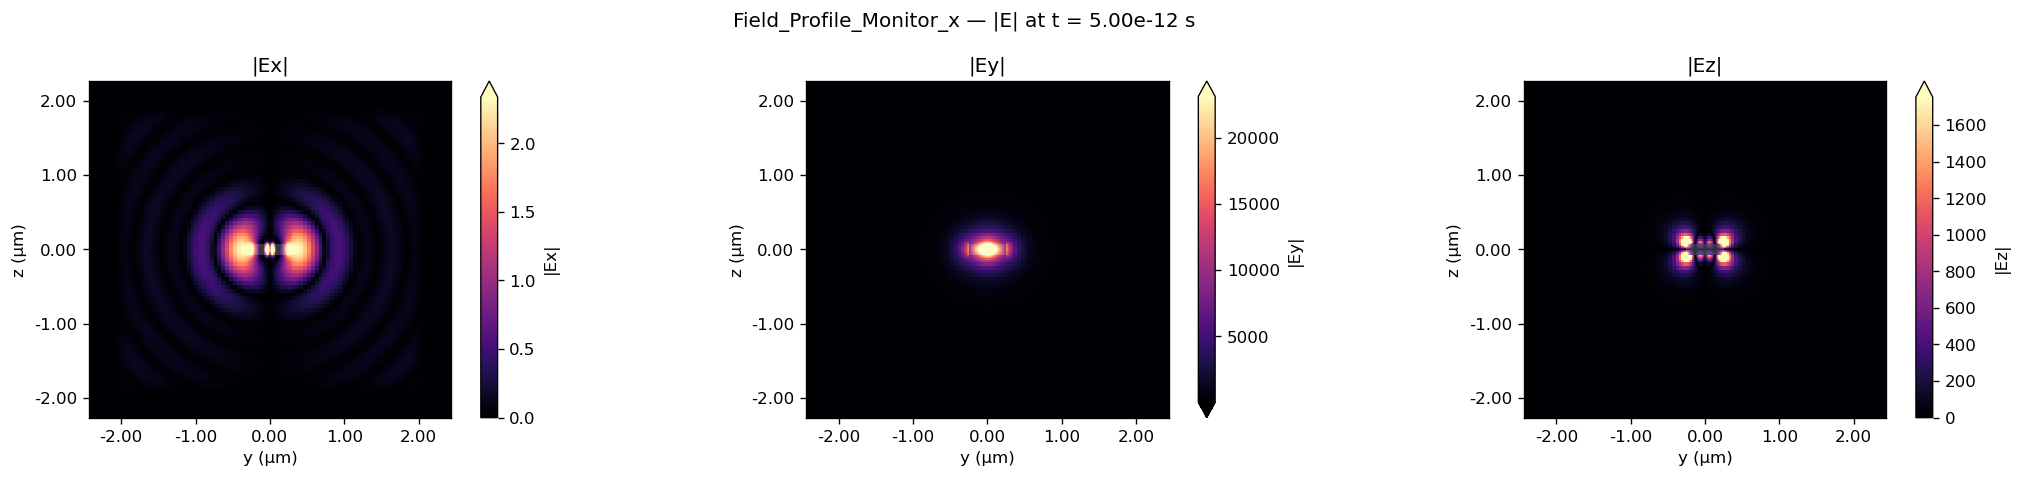

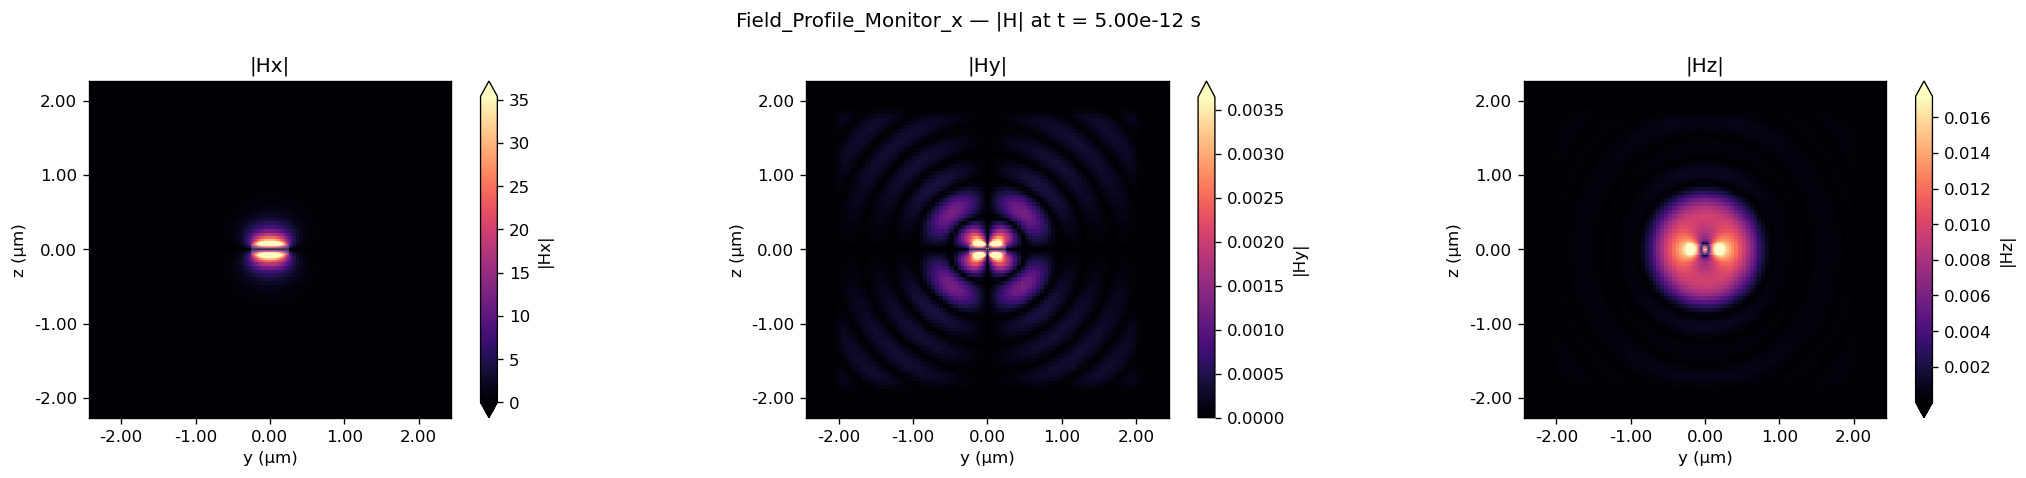

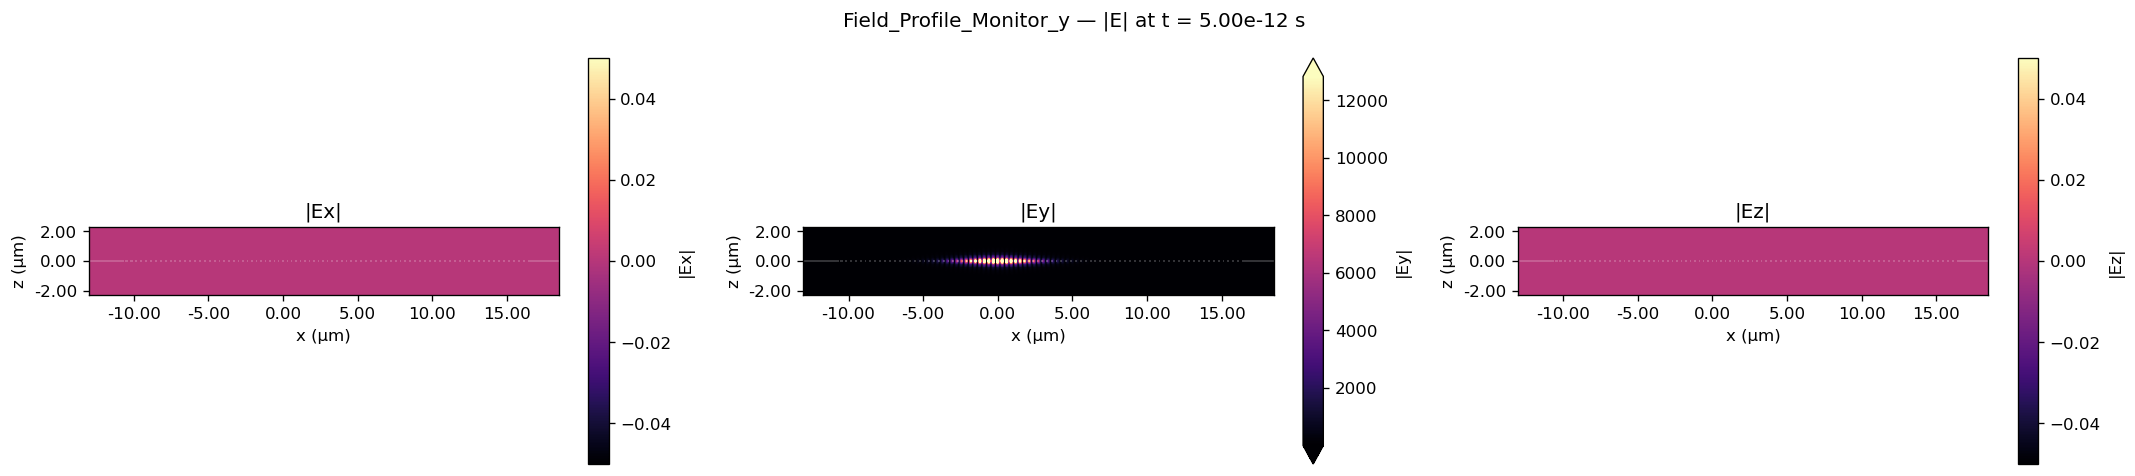

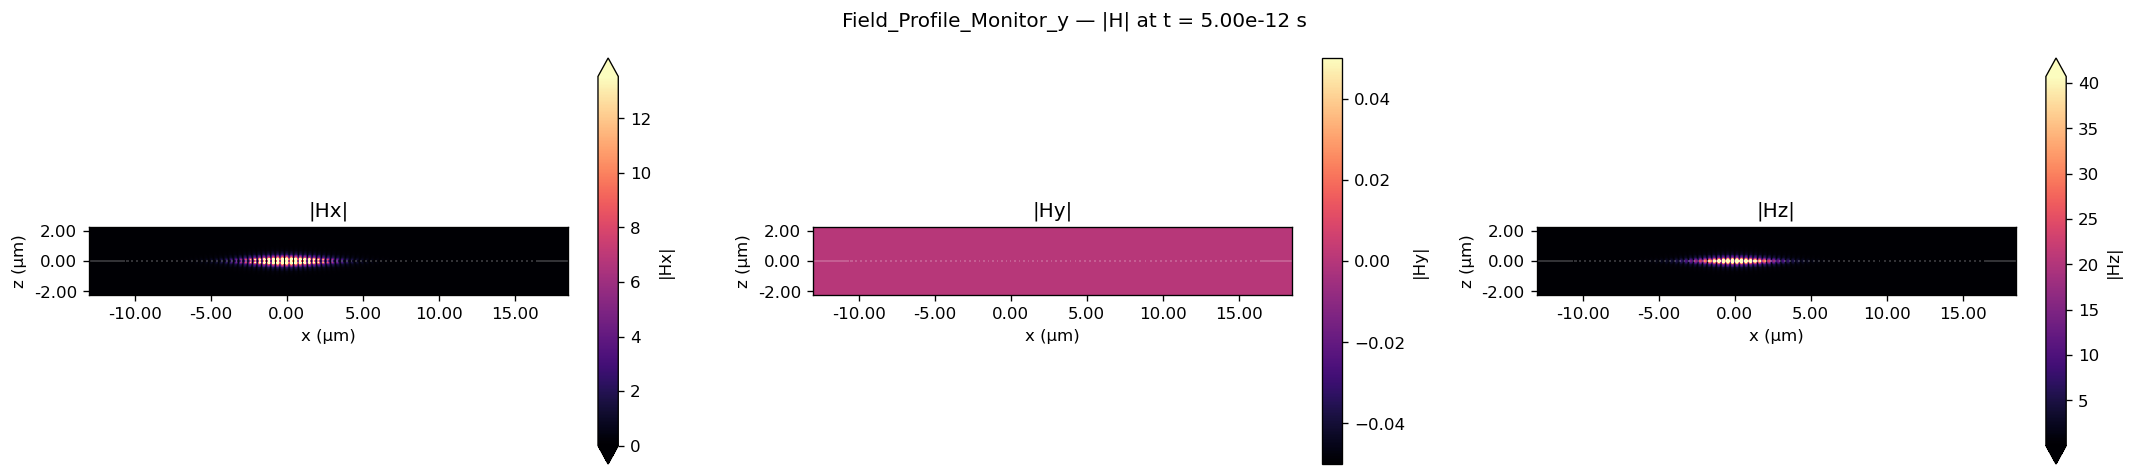

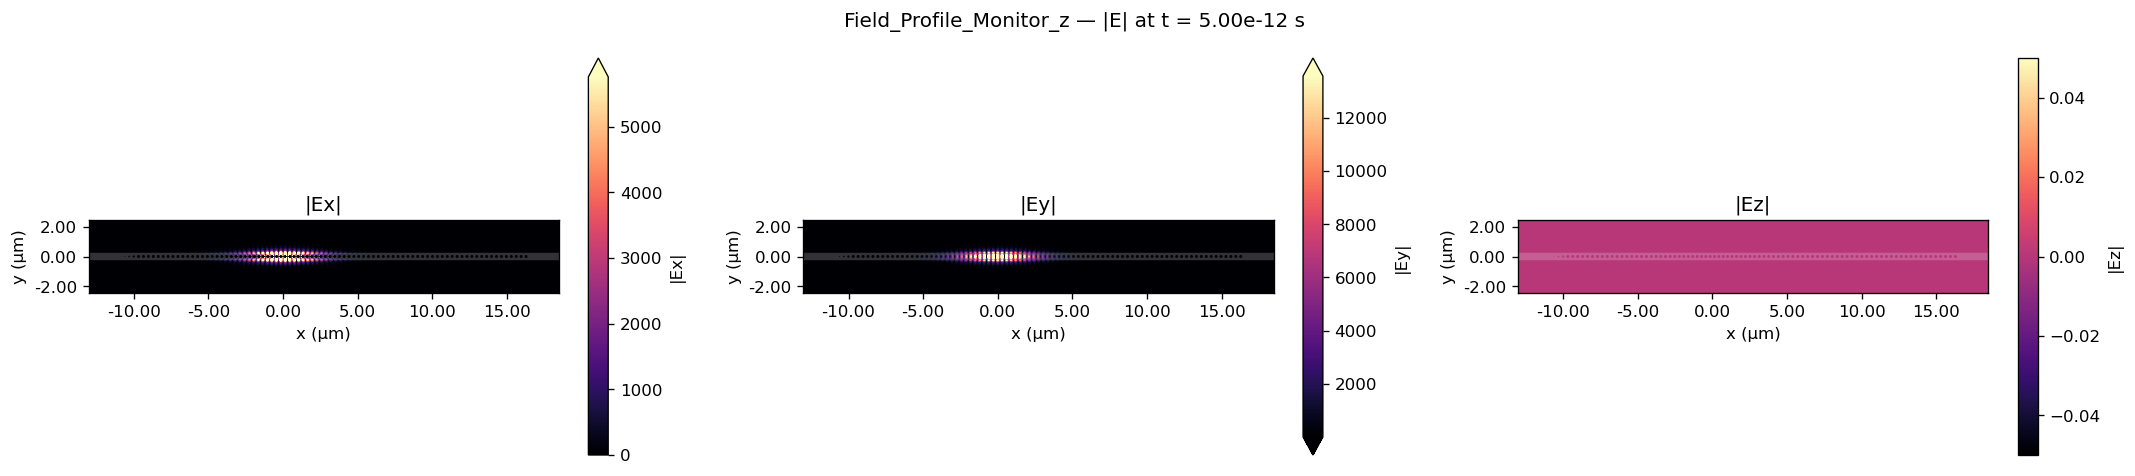

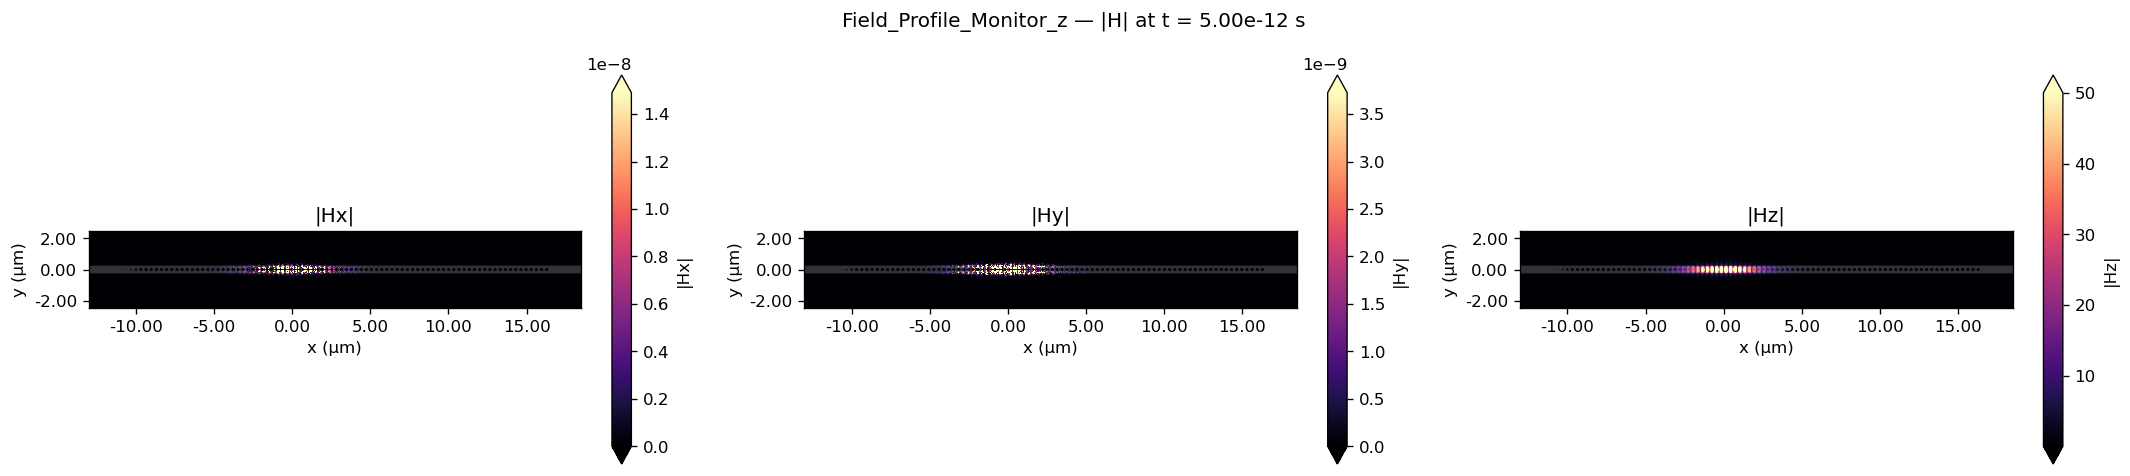

In [9]:
cavity.full_analysis()
cavity.simulation.plot_results()

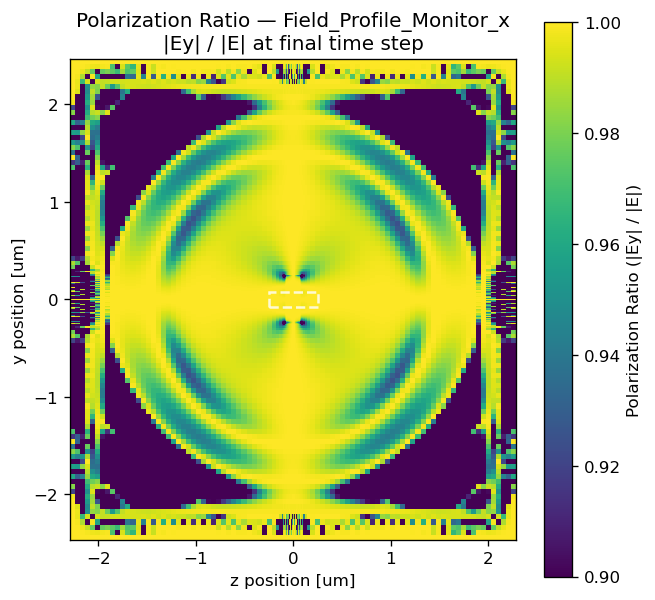

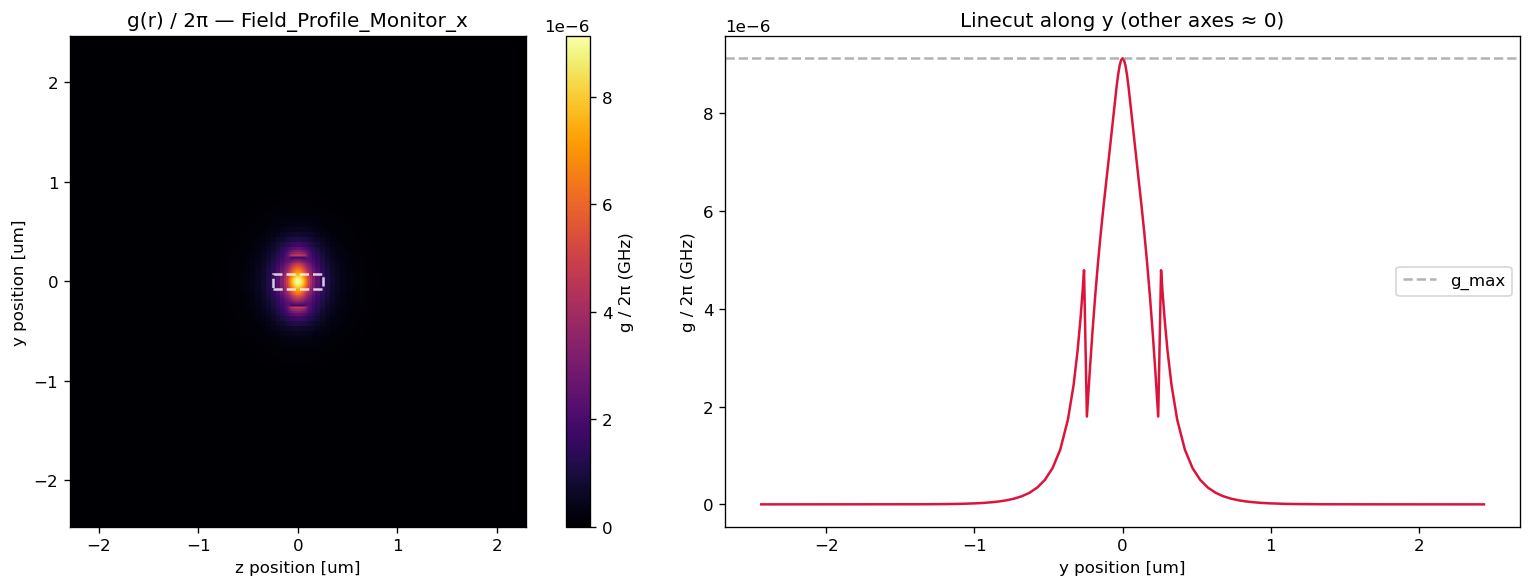

g_max / 2π = 0.0000 GHz
κ / 2π     = 0.0468 GHz
g / κ      = 0.00


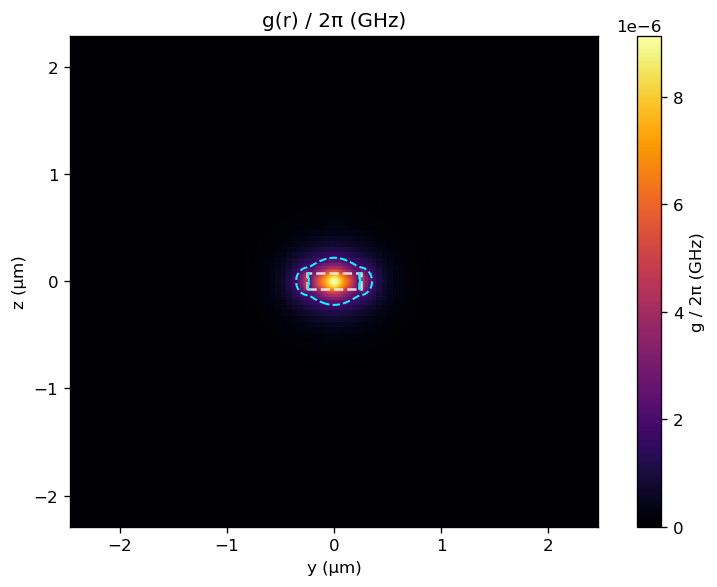

g_max / 2π = 0.0000 GHz
κ / 2π     = 0.0468 GHz
g / κ      = 0.00


In [ ]:
sim_obj.polarization_profile(monitor_name="Field_Profile_Monitor_x", polarization_component="Ey", plot=True)

dipole_moment = 3.58*1e-29 # Cm
g_map, g_max = sim_obj.coupling_g(dipole_moment=dipole_moment, monitor_name="Field_Profile_Monitor_x", polarization_component="Ey", plot=True)

### GDS TEST

In [9]:
import gdspy

gdspy.current_library = gdspy.GdsLibrary()
gds_lib = gdspy.GdsLibrary(unit=1e-6, precision=1e-9)

cell = gds_lib.new_cell('beam_with_holes')

start_beam = cavity.beam_layout['positions'][0] - 1
end_beam = cavity.beam_layout['positions'][-1] + 1  
length_x = end_beam - start_beam
length_y = width

beam = gdspy.Rectangle((start_beam, -length_y/2), (end_beam, length_y/2), layer=1)
holes = []

for i, x in enumerate(cavity.beam_layout['positions']):
    rx = float(cavity.beam_layout['hole_params'][i, 0])/2
    ry = float(cavity.beam_layout['hole_params'][i, 1])/2

    hole = gdspy.Round((x, 0.0), radius = (rx, ry), number_of_points=32)    
    holes.append(hole)
    #cell.add(hole)
    
#cell.add(beam)

inverted_geometry = gdspy.boolean(beam, holes, 'not', layer=1, datatype=0)
cell.add(inverted_geometry)

wgd = gdspy.Rectangle((-100, -length_y/2), (start_beam, length_y/2), layer=2)
cell.add(wgd)


poli = gdspy.Polygon([(-4000, -thickness/2),(-4000, thickness/2),(-100,length_y/2),(-100,-length_y/2)], layer=2)
cell.add(poli)


array_cell = gds_lib.new_cell('beam_with_holes_array')

N = 1           # number of repeats
dy = 12.7         # spacing in y (in your library units; here it's microns if unit=1e-6)

text_layer = 10
text_dtype = 0
text_height = 3.0   # text size in your units (microns if unit=1e-6)

# Where to place the number relative to each repeated structure:
x_label = -5      # pick something in your layout
y_label_offset = 2  # relative to each copy's origin

for k in range(N):
    y0 = k * dy

    # Place the structure
    array_cell.add(gdspy.CellReference(cell, origin=(0, y0)))

    # Add the number label
    label = gdspy.Text(
        str(k),                      # or str(k+1) if you want 1..N
        text_height,
        position=(x_label, y0 + y_label_offset),
        layer=text_layer,
        datatype=text_dtype
    )
    array_cell.add(label)

gds_lib.write_gds('test_punched.gds')


In [10]:
import gdspy

gdspy.current_library = gdspy.GdsLibrary()
gds_lib = gdspy.GdsLibrary(unit=1e-6, precision=1e-9)

cell = gds_lib.new_cell('beam_with_holes')

start_beam = cavity.beam_layout['positions'][0] - 1
end_beam = cavity.beam_layout['positions'][-1] + 1  
length_x = end_beam - start_beam
length_y = width

beam = gdspy.Rectangle((start_beam, -length_y/2), (end_beam, length_y/2), layer=1)
holes = []

for i, x in enumerate(cavity.beam_layout['positions']):
    rx = float(cavity.beam_layout['hole_params'][i, 0])/2
    ry = float(cavity.beam_layout['hole_params'][i, 1])/2

    hole = gdspy.Round((x, 0.0), radius = (rx, ry), number_of_points=32, layer=0)    
    holes.append(hole)
    #cell.add(hole)
    
cell.add(beam)
cell.add(holes)

#inverted_geometry = gdspy.boolean(beam, holes, 'not', layer=1, datatype=0)
#cell.add(inverted_geometry)

wgd = gdspy.Rectangle((-100, -length_y/2), (start_beam, length_y/2), layer=2)
cell.add(wgd)


poli = gdspy.Polygon([(-4000, -thickness/2),(-4000, thickness/2),(-100,length_y/2),(-100,-length_y/2)], layer=2)
cell.add(poli)


array_cell = gds_lib.new_cell('beam_with_holes_array')

N = 1           # number of repeats
dy = 12.7         # spacing in y (in your library units; here it's microns if unit=1e-6)

text_layer = 10
text_dtype = 0
text_height = 3.0   # text size in your units (microns if unit=1e-6)

# Where to place the number relative to each repeated structure:
x_label = -5      # pick something in your layout
y_label_offset = 2  # relative to each copy's origin

for k in range(N):
    y0 = k * dy

    # Place the structure
    array_cell.add(gdspy.CellReference(cell, origin=(0, y0)))

    # Add the number label
    label = gdspy.Text(
        str(k),                      # or str(k+1) if you want 1..N
        text_height,
        position=(x_label, y0 + y_label_offset),
        layer=text_layer,
        datatype=text_dtype
    )
    array_cell.add(label)

gds_lib.write_gds('test_not_punched.gds')


# Design 2

In [34]:
thickness = 0.25
width = 0.5
wl0 = 0.78
freq0 = C0 / wl0

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 135 x 135.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 8.33333, 0)
     (0, 0, 8.33333)
Cell volume = 69.4444
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.12, -0)
     (0, -0, 0.12)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1.66667,0.833333)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.666667,0.666667,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -4.2284..4.2284, -4.2284..4.2284)
          bounding box (-0.333333..0.333333, -0.333333..0.333333, -5e+19..5e+19)
          shift object by (0, 0, -8.33333)
          ellipsoid, center = (0,0,0)
               size (0.666667,0.666667,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding box 

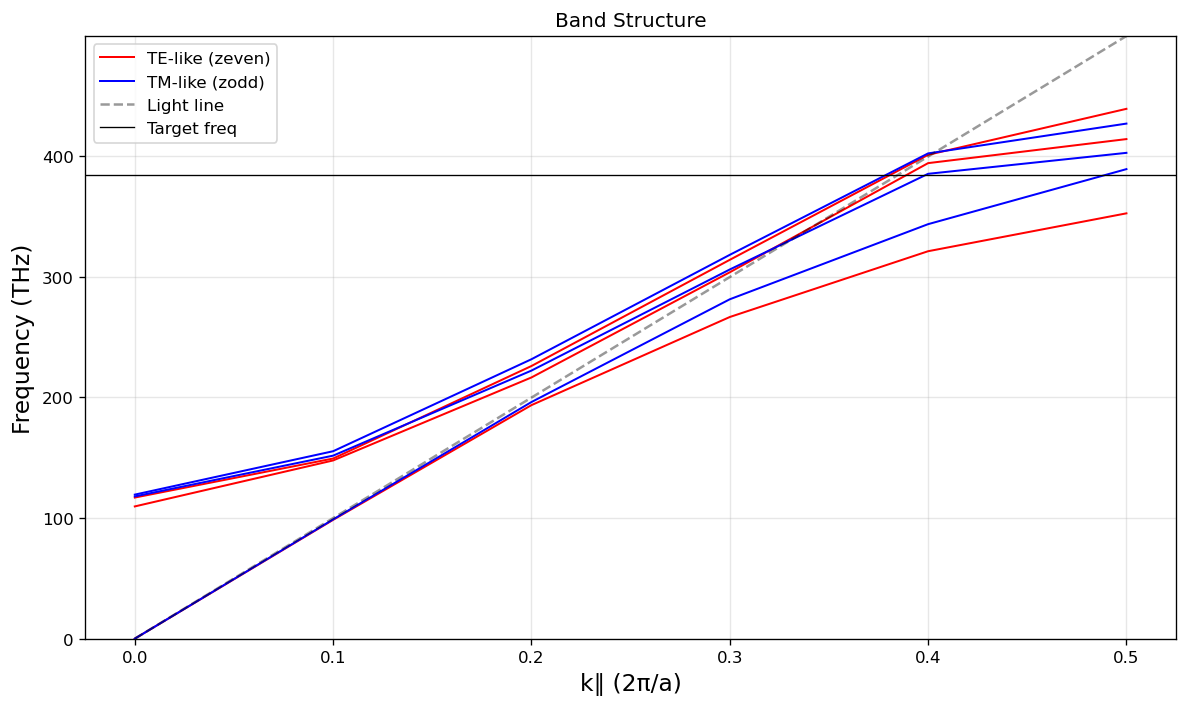

(<Figure size 1200x720 with 1 Axes>,
 <Axes: title={'center': 'Band Structure'}, xlabel='k∥ (2π/a)', ylabel='Frequency (THz)'>)

In [35]:
Lx = 0.3
Ly = width
dx = 0.2
dy = 0.2

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=4)
sim.plot_bands(units='THz', freq0_Hz=freq0)

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 160 x 160.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 9.61538, 0)
     (0, 0, 9.61538)
Cell volume = 92.4556
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.104, -0)
     (0, -0, 0.104)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1.92308,0.961538)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.769231,0.769231,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -4.86779..4.86779, -4.86779..4.86779)
          bounding box (-0.384615..0.384615, -0.384615..0.384615, -5e+19..5e+19)
          shift object by (0, 0, -9.61538)
          ellipsoid, center = (0,0,0)
               size (0.769231,0.769231,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          boundin

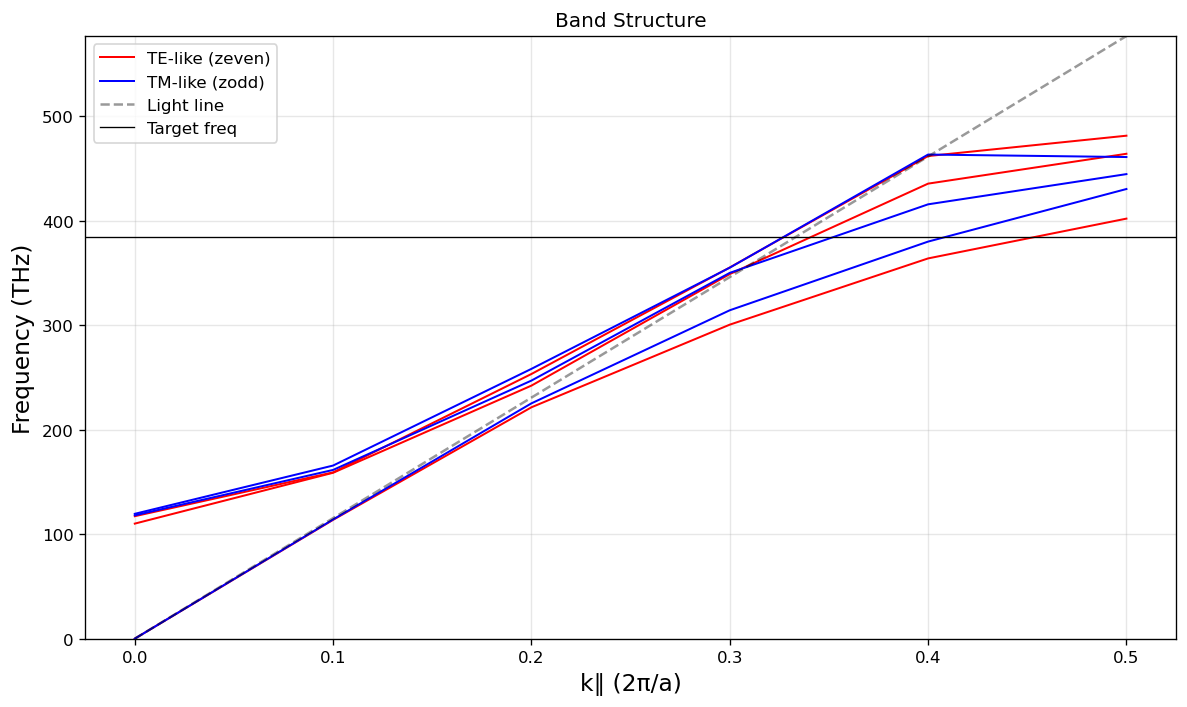

epsilon: 1-4, mean 1.04552, harm. mean 1.01251, 1.78394% > 1, 1.51731% "fill"
real part range: 1 .. 4


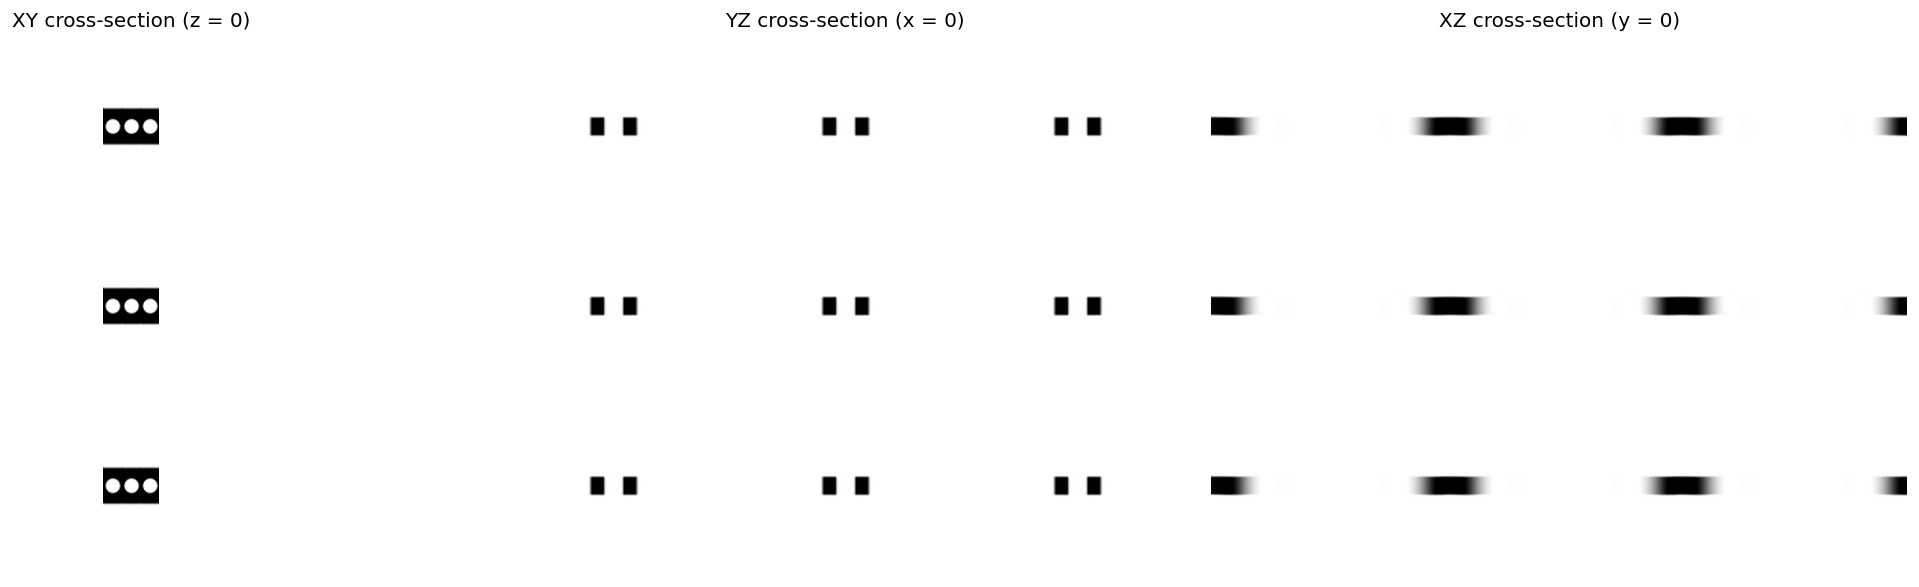

(<Figure size 2160x600 with 3 Axes>,
 array([<Axes: title={'center': 'XY cross-section (z = 0)'}, xlabel='x', ylabel='y'>,
        <Axes: title={'center': 'YZ cross-section (x = 0)'}, xlabel='y', ylabel='z'>,
        <Axes: title={'center': 'XZ cross-section (y = 0)'}, xlabel='x', ylabel='z'>],
       dtype=object))

In [36]:
Lx = 0.26
Ly = width
dx = 0.2
dy = 0.2

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=4)
sim.plot_bands(units='THz', freq0_Hz=freq0)

sim.plot_epsilon(periods=3)

12:43:23 PDT WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

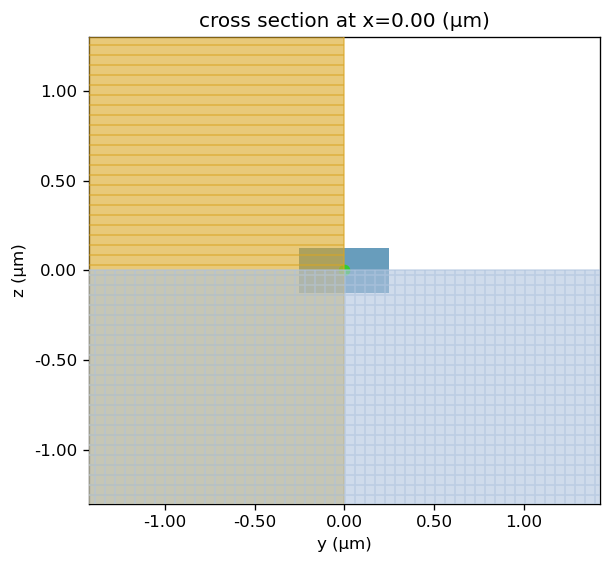

                         wavelength     n eff  k eff  TE (Ey) fraction  \
f            mode_index                                                  
3.843493e+14 0                 0.78  1.610650    0.0          0.994391   
             1                 0.78  0.986114    0.0          0.995182   

                         wg TE fraction  wg TM fraction  mode area  
f            mode_index                                             
3.843493e+14 0                 0.848624        0.858304   0.155865  
             1                 0.989982        0.981379   4.608022  


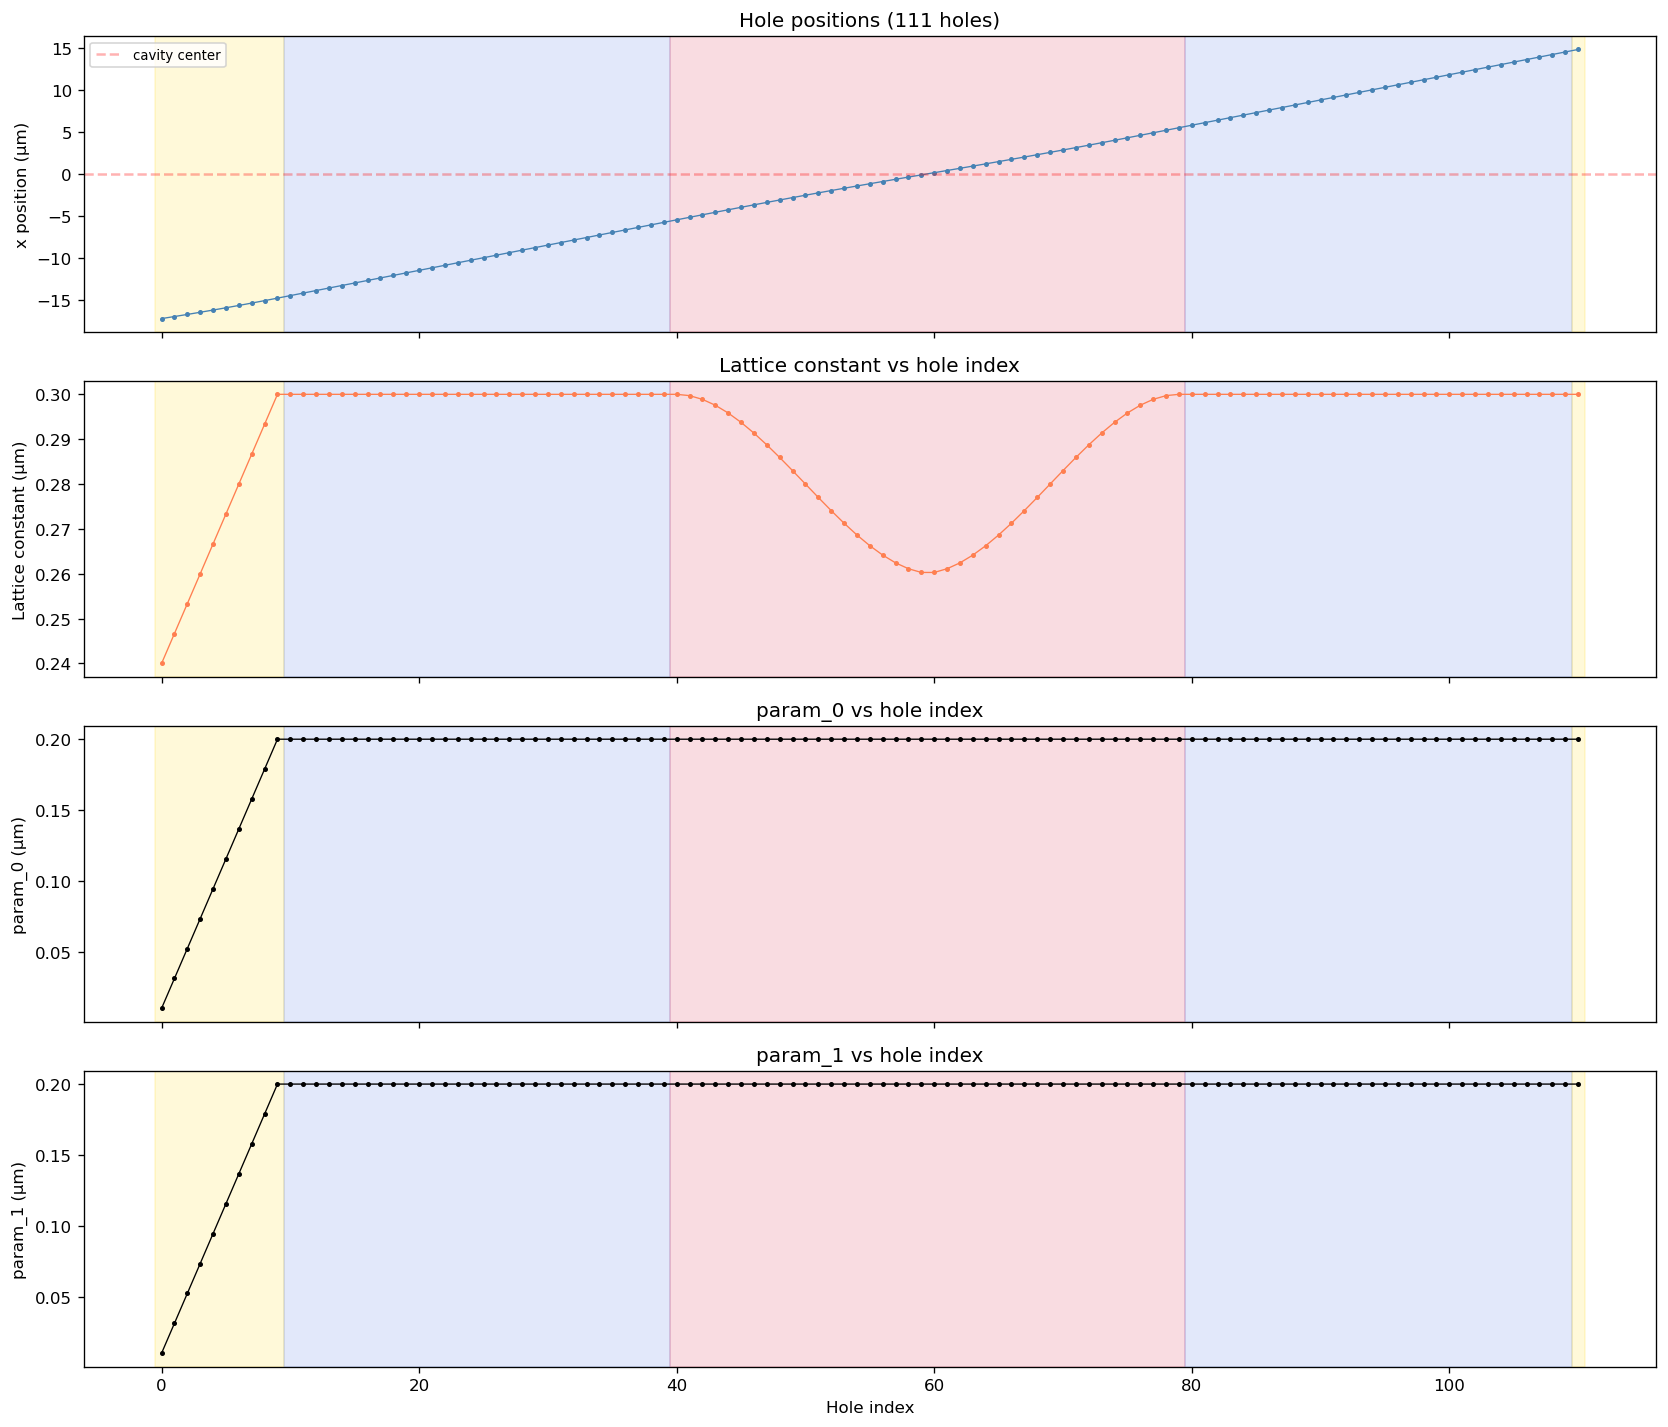

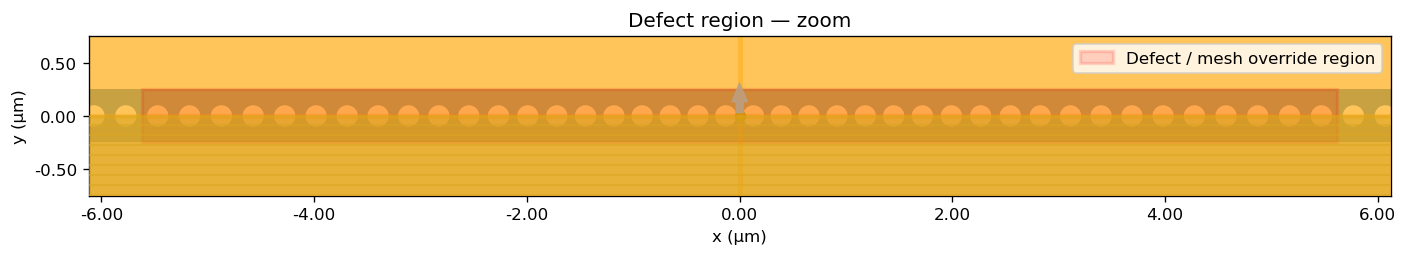

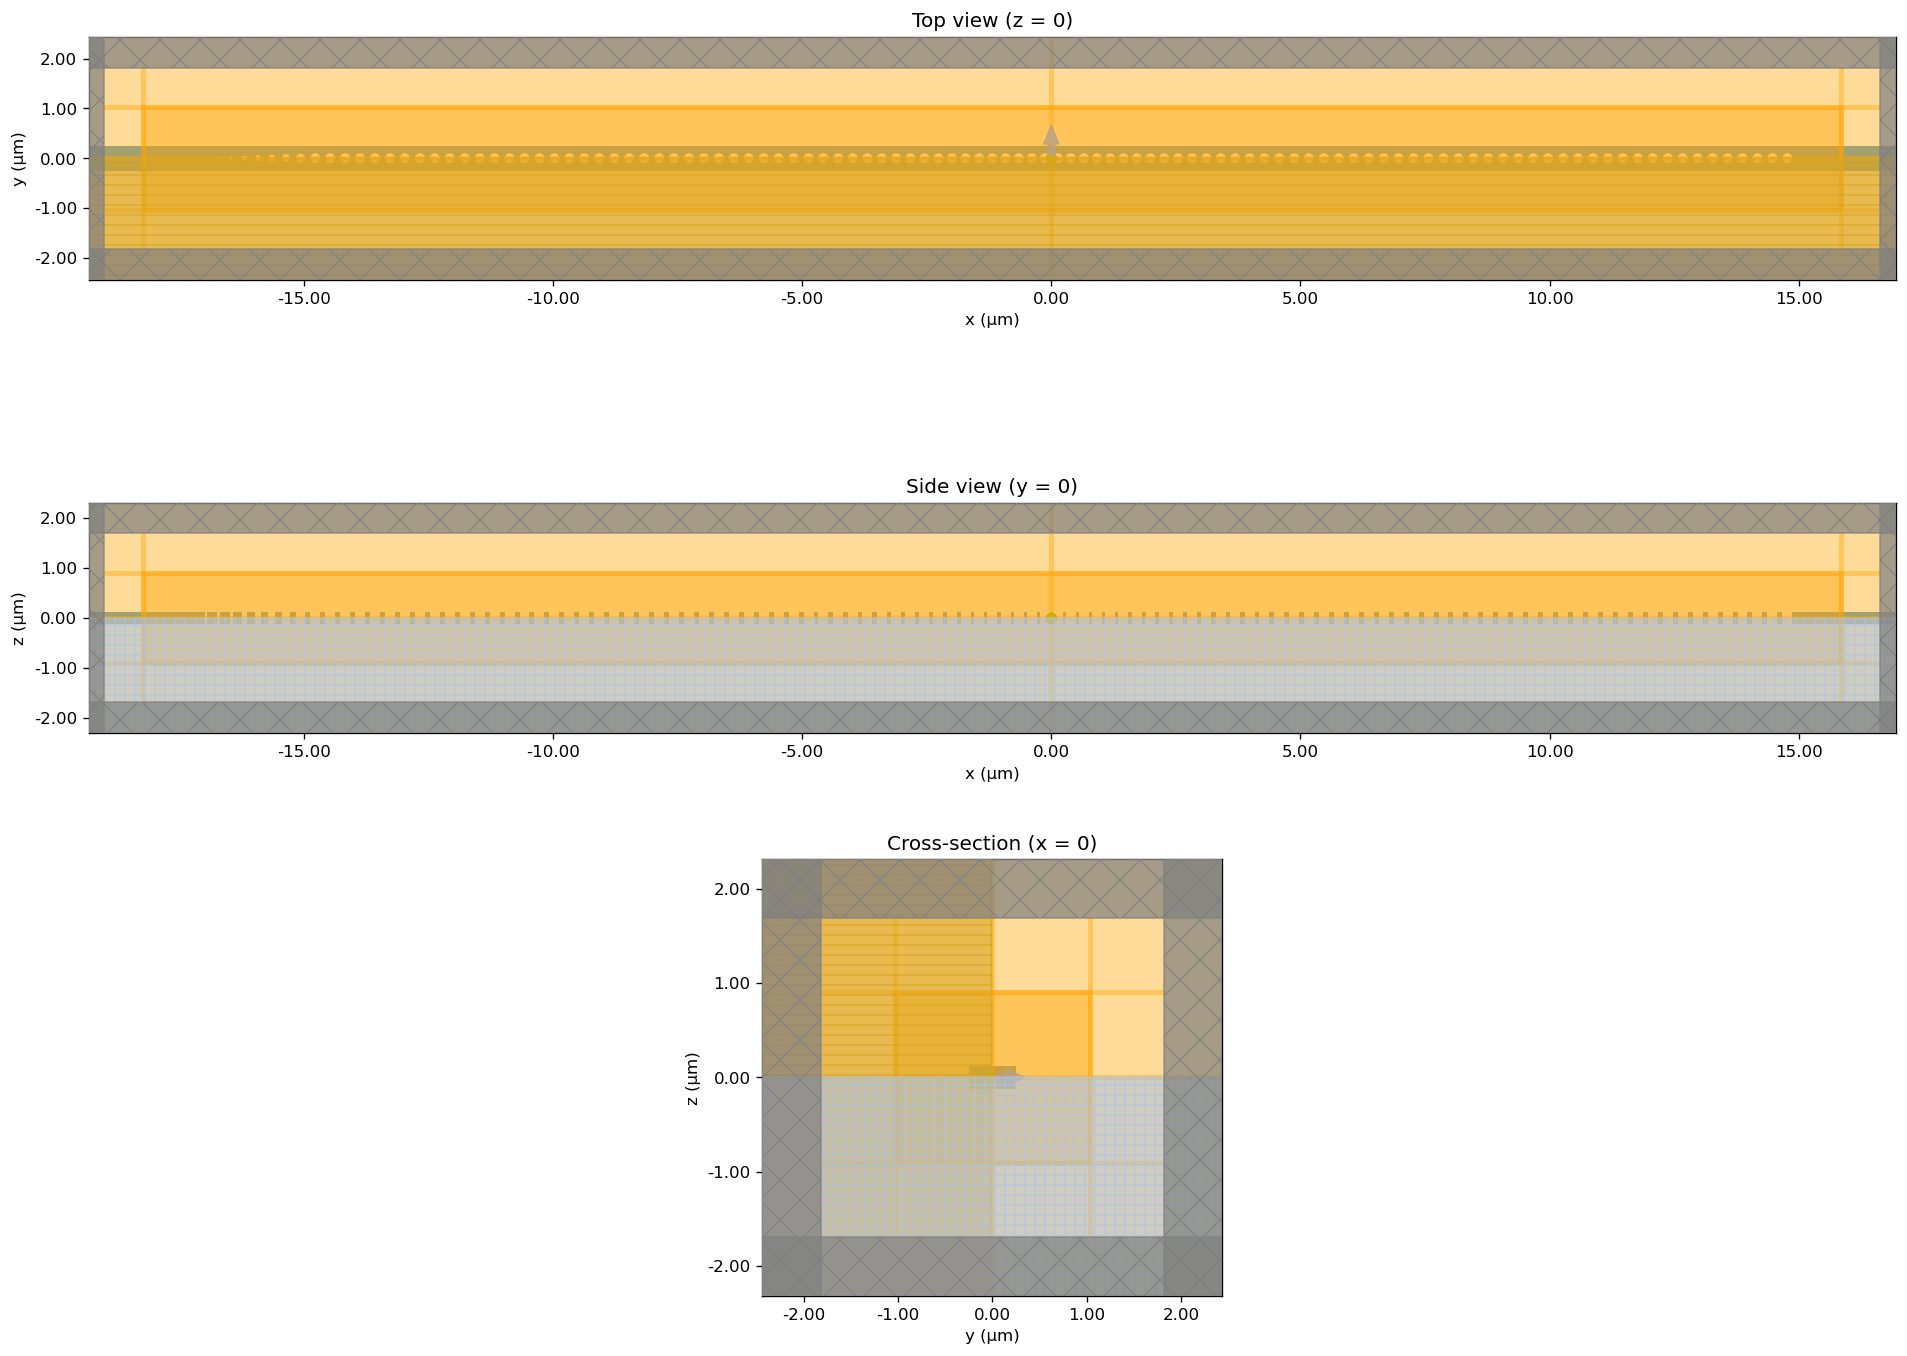

mode n_eff: [1.61064997 0.98611426]
mode k_wg: [12.97437462  7.9435111 ]
mode a_last: [0.24213827 0.39549169]


In [ ]:
n_cells = {
    "N_left_taper":    10,
    "N_left_mirror":  10,
    "N_defect":       41,   # odd → includes a central cell
    "N_right_mirror": 30,
    "N_right_taper":   1,
}

parameters = {
    "parameters_taper_left":    {"lattice": 0.24, "hole_params": np.array([0.01, 0.01])},
    "parameters_mirrors_left":  {"lattice": 0.3, "hole_params": np.array([0.2, 0.2])},
    "parameters_defect":        {"lattice": 0.26,  "hole_params": np.array([0.2, 0.2])},
    "parameters_mirrors_right": {"lattice": 0.3, "hole_params": np.array([0.2, 0.2])},
    "parameters_taper_right":   {"lattice": 0.24, "hole_params": np.array([0.01, 0.01])},
}

fwidth = freq0 * 0.01

context = {
    "freq0":          freq0,       # centre frequency (1/µm)
    "fwidth":         fwidth,        # bandwidth
    "thickness":      thickness,       # slab thickness (µm)
    "width":          width,       # waveguide width (µm)
    "polarization":   "Ey",       # dipole polarization (TE-like)
    "medium":         2.0,          # material name (file-based dispersion) or refractive index
    "mode":           "dielectric",
    "sidewall_angle":  0,
    "geometry":       "ellipse",  # hole shape: 'ellipse' or 'square'
}


cavity2 = Cavity(n_cells=n_cells, parameters=parameters, context=context)

sim = cavity2.build_simulation(
    grid_size_override=(0.01, 0.01, 0.01),  # coarser mesh for quick testing
    num_modes=2,
    plot=True,  # show mode solve results
)

cavity2.plot_simulation()

print("mode n_eff:", sim.n_eff)
print("mode k_wg:", sim.k_wg)
print("mode a_last:", sim.a_last)

In [ ]:
sim_obj = cavity2.simulation

sim_obj.upload(directory="cavities_780", save_name="design_2")
sim_obj.estimate_cost()
sim_data = sim_obj.run(directory="cavities_780", save_name="design_2")
cavity2.full_analysis()
cavity2.simulation.plot_results()


12:46:47 PDT Created task 'design_2' with task_id                               
             'fdve-af861464-4b26-484d-b41e-466f466dbcf5' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=233517;https://tidy3d.simulation.cloud/workbench?taskId=fdve-af861464-4b26-484d-b41e-466f466dbcf5\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=827776;https://tidy3d.simulation.cloud/workbench?taskId=fdve-af861464-4b26-484d-b41e-466f466dbcf5\taskId]8;;\]8;id=233517;https://tidy3d.simulation.cloud/workbench?taskId=fdve-af861464-4b26-484d-b41e-466f466dbcf5\=]8;;\]8;id=975678;https://tidy3d.simulation.cloud/workbench?taskId=fdve-af861464-4b26-484d-b41e-466f466dbcf5\fdve]8;;\]8;id=233517;https://tidy3d.simulation.cloud/workbench?taskId=fdve-af861464-4b26-484d-b41e-466f466dbcf5\-af861464-4b2]8;;\
             ]8;id=233517;https://tidy3d.simulation.cloud/workbench?taskId=fdve-af861464-4b26-484d-b41e-466f466dbcf5\6-484d-b41e-466f466dbcf5']8;;\.

             Task folder: ]8;id=933196;https://tidy3d.simulation.cloud/folders/folder-8c7a9030-ac93-4419-9556-0063911176c6\'cavities_780']8;;\.

Output()

12:46:49 PDT Maximum FlexCredit cost: 0.765. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

12:55:18 PDT status = success

12:55:20 PDT View simulation result at                                          
             ]8;id=892033;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0f90ab38-30c8-46ed-aaa1-c0aca10d4587\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=340004;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0f90ab38-30c8-46ed-aaa1-c0aca10d4587\taskId]8;;\]8;id=892033;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0f90ab38-30c8-46ed-aaa1-c0aca10d4587\=]8;;\]8;id=632175;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0f90ab38-30c8-46ed-aaa1-c0aca10d4587\fdve]8;;\]8;id=892033;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0f90ab38-30c8-46ed-aaa1-c0aca10d4587\-0f90ab38-30c]8;;\
             ]8;id=892033;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0f90ab38-30c8-46ed-aaa1-c0aca10d4587\8-46ed-aaa1-c0aca10d4587']8;;\.

Output()

12:55:23 PDT loading simulation from cavities_780/design_2.hdf5

Results saved: cavities_780/design_2.hdf5


# Design 3

In [37]:
thickness = 0.4
width = 0.6
wl0 = 0.78
freq0 = C0 / wl0

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 160 x 135.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 10, 0)
     (0, 0, 8.33333)
Cell volume = 83.3333
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.1, -0)
     (0, -0, 0.12)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2,0.833333)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.666667,0.866667,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -5.0625..5.0625, -4.2284..4.2284)
          bounding box (-0.333333..0.333333, -0.433333..0.433333, -5e+19..5e+19)
          shift object by (0, 0, -8.33333)
          ellipsoid, center = (0,0,0)
               size (0.666667,0.866667,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding box (-0.333333..

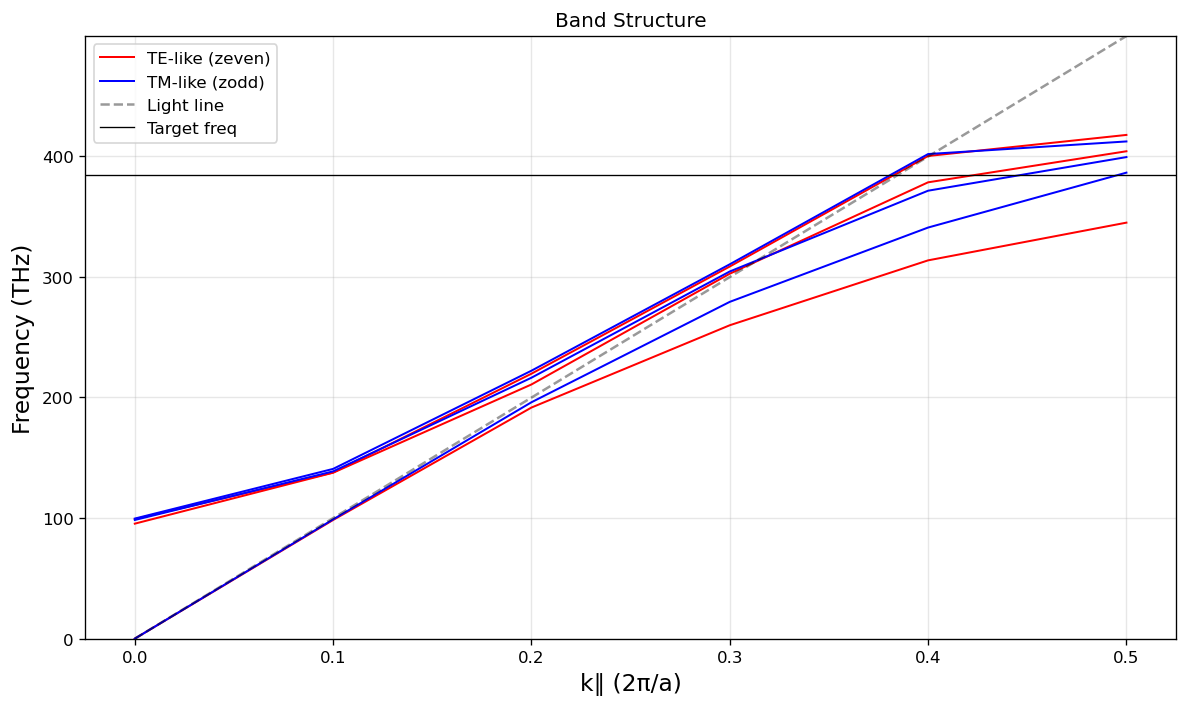

(<Figure size 1200x720 with 1 Axes>,
 <Axes: title={'center': 'Band Structure'}, xlabel='k∥ (2π/a)', ylabel='Frequency (THz)'>)

In [32]:
Lx = 0.3
Ly = width
dx = 0.2
dy = 0.2*1.3

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=4)
sim.plot_bands(units='THz', freq0_Hz=freq0)

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 175 x 144.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 10.7143, 0)
     (0, 0, 8.92857)
Cell volume = 95.6633
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.0933333, -0)
     (0, -0, 0.112)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2.14286,0.892857)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.714286,0.928571,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -5.41837..5.41837, -4.52629..4.52629)
          bounding box (-0.357143..0.357143, -0.464286..0.464286, -5e+19..5e+19)
          shift object by (0, 0, -8.92857)
          ellipsoid, center = (0,0,0)
               size (0.714286,0.928571,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bou

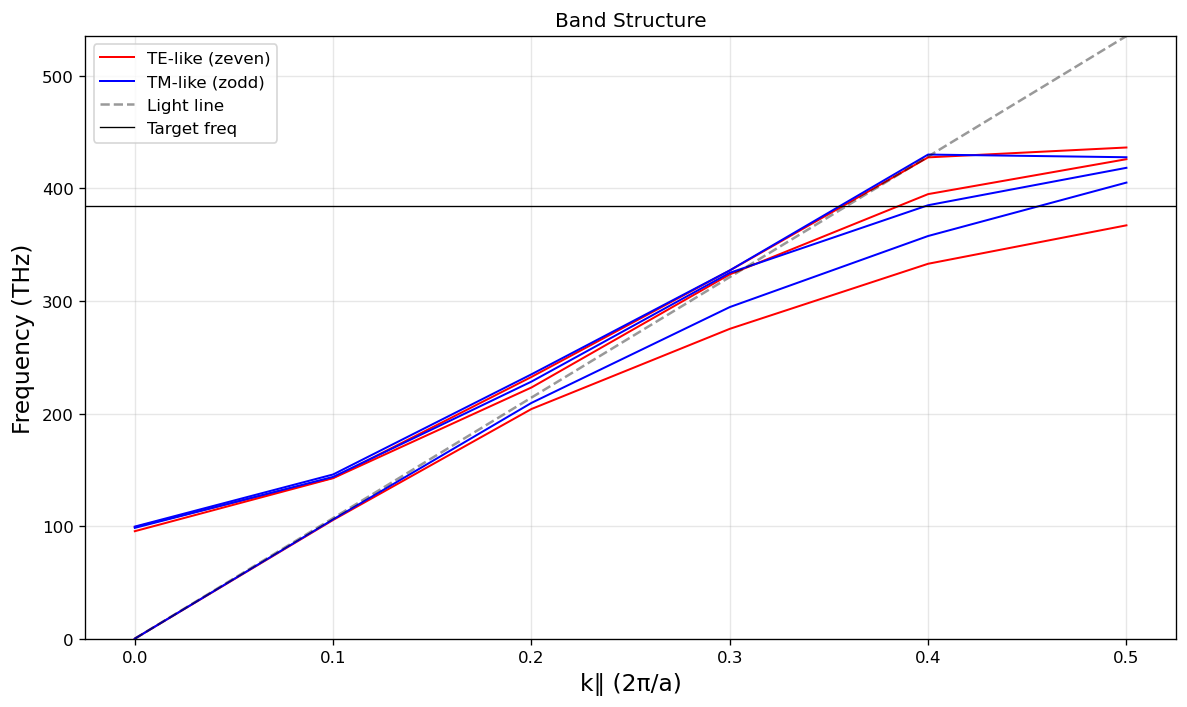

(<Figure size 1200x720 with 1 Axes>,
 <Axes: title={'center': 'Band Structure'}, xlabel='k∥ (2π/a)', ylabel='Frequency (THz)'>)

In [33]:
Lx = 0.28
Ly = width
dx = 0.2
dy = 0.2*1.3

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=4)
sim.plot_bands(units='THz', freq0_Hz=freq0)

In [ ]:
n_cells = {
    "N_left_taper":    10,
    "N_left_mirror":  30,
    "N_defect":       40,   # odd → includes a central cell
    "N_right_mirror": 30,
    "N_right_taper":   1,
}

parameters = {
    "parameters_taper_left":    {"lattice": 0.24, "hole_params": np.array([0.01, 0.01])},
    "parameters_mirrors_left":  {"lattice": 0.3, "hole_params": np.array([0.2, 0.2])},
    "parameters_defect":        {"lattice": 0.26,  "hole_params": np.array([0.2, 0.2])},
    "parameters_mirrors_right": {"lattice": 0.3, "hole_params": np.array([0.2, 0.2])},
    "parameters_taper_right":   {"lattice": 0.24, "hole_params": np.array([0.01, 0.01])},
}

fwidth = freq0 * 0.01

context = {
    "freq0":          freq0,       # centre frequency (1/µm)
    "fwidth":         fwidth,        # bandwidth
    "thickness":      thickness,       # slab thickness (µm)
    "width":          width,       # waveguide width (µm)
    "polarization":   "Ey",       # dipole polarization (TE-like)
    "medium":         2.0,          # material name (file-based dispersion) or refractive index
    "mode":           "dielectric",
    "sidewall_angle":  0,
    "geometry":       "ellipse",  # hole shape: 'ellipse' or 'square'
}


cavity = Cavity(n_cells=n_cells, parameters=parameters, context=context)

sim = cavity.build_simulation(
    grid_size_override=(0.01, 0.01, 0.01),  # coarser mesh for quick testing
    num_modes=2,
    plot=True,  # show mode solve results
)

cavity.plot_simulation()

print("mode n_eff:", sim.n_eff)
print("mode k_wg:", sim.k_wg)
print("mode a_last:", sim.a_last)

In [ ]:
sim_obj = cavity.simulation

sim_obj.upload(directory="cavities_780", save_name="design_3")
sim_obj.estimate_cost()
sim_data = sim_obj.run(directory="cavities_780", save_name="design_3")
cavity.full_analysis()
cavity.simulation.plot_results()